<a href="https://colab.research.google.com/github/aulukic/diplomski-rad/blob/main/notebook/Final_Benchmarking.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Komparativna analiza performansi algoritama stabala odlučivanja i ansambala

Ova Jupyter bilježnica sadrži cjelokupni programski kod, eksperimentalne postavke i rezultate za potrebe diplomskog rada. Istraživanje se fokusira na usporedbu prediktivnih performansi i empirijske složenosti (vremena izvođenja) klasičnih stabala odlučivanja u odnosu na moderne ansamble, uz korištenje CPU i GPU hardverske akceleracije.

## Skupovi podataka i tipovi analize

Eksperiment se provodi nad pet standardnih skupova podataka iz UCI repozitorija, obuhvaćajući probleme klasifikacije i regresije, kao i izazove neuravnoteženih klasa (imbalanced data):
1. **Iris** (Višeklasna klasifikacija)
2. **Bank Marketing** (Binarna klasifikacija uz snažan disbalans klasa)
3. **Adult** (Regresija - predviđanje radnih sati `hours-per-week`)
4. **Wine Quality** (Višeklasna klasifikacija / Regresija)
5. **Breast Cancer Wisconsin** (Binarna klasifikacija medicinskih podataka)

## Korišteni algoritmi i hardverske postavke
Svi modeli su konfigurirani sa fiksnim *random state* parametrom radi potpune reproducibilnosti rezultata.
- **CART (Gini/Entropy)** - Klasično stablo (`DecisionTreeClassifier/Regressor`)
- **Random Forest** - Sekvencijalni ansambl (CPU paralelizacija, `n_jobs=-1`)
- **XGBoost (CPU)** - Ekstremni gradijentni boosting (CPU arhitektura)
- **XGBoost (GPU)** - Akcelerirani boosting na NVIDIA RTX 4070 CUDA arhitekturi (`device='cuda'`)

## Metodologija evaluacije
- **K-Fold Cross-Validation:** $k=10$ uz stratifikaciju klasa za klasifikacijske probleme.
- **Pretprocesiranje (Pipeline):** `SimpleImputer`, `StandardScaler`, `OneHotEncoder`.
- **Statistička značajnost:** Nadeau & Bengio korigirani upareni t-test (za pojedinačne skupove) i Friedman + Nemenyi Post-Hoc test (za globalni rang algoritama).

---

## Instalacija dodatnih biblioteka za Google Colab okruženje


In [ ]:
# ==============================================================================
# INSTALACIJA DODATNIH BIBLIOTEKA
# ==============================================================================

print("Započinjem instalaciju potrebnih paketa...")
!pip install scikit-posthocs
!pip install shap
!pip install chefboost

print("Instalacija završena!")

## Uvoz svih potrebnih biblioteka

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import os
import gc
import warnings

# Strojno učenje (Scikit-Learn i XGBoost)
from sklearn.model_selection import KFold, cross_validate
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, plot_tree
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, mean_squared_error
import xgboost as xgb

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split

# Objašnjivost (XAI)
import shap

# Statističko testiranje
from scipy import stats
import scikit_posthocs as sp

# Edukativni algoritam (Opcionalno za Iris)
from chefboost import Chefboost as chef

# Uklanjanje dosadnih crvenih upozorenja (Warnings) radi čistoće ispisa
warnings.filterwarnings('ignore')

# Postavljanje vizualnog stila za grafove
sns.set_theme(style="whitegrid")
plt.rcParams['figure.dpi'] = 100

print("   Sve biblioteke su uspješno učitane!")

   Sve biblioteke su uspješno učitane!


## Učitavanje svih skupova podataka s Google Drivea ili lokalno

In [8]:
import os
import sys
import pandas as pd

# ==============================================================================
# KONFIGURACIJA OKRUŽENJA I PRIORITETA UČITAVANJA
# ==============================================================================
# Korisnik može forsirati ignoriranje Drive-a čak i u Colabu (npr. mentor)
USE_DRIVE_IF_AVAILABLE = True

# Detekcija okruženja
IN_COLAB = 'google.colab' in sys.modules

# Definiranje imena mape na Driveu i lokalno (neka budu ista radi lakšeg rada)
FOLDER_NAME = 'diplomski_rad_podaci'
DRIVE_BASE = f'/content/drive/MyDrive/{FOLDER_NAME}'
COLAB_LOCAL = '/content/'
PC_LOCAL = f'./{FOLDER_NAME}/' # Mapa u istom direktoriju gdje je .ipynb na laptopu

base_path = ""
results_path = ""

if IN_COLAB:
    from google.colab import drive # <--- DODANO OVDJE (Sigurno mjesto)
    if USE_DRIVE_IF_AVAILABLE:
        print("Okruženje: Google Colab. Pokušavam montirati Drive...")
        try:
            drive.mount('/content/drive', force_remount=True)
            if os.path.exists(DRIVE_BASE):
                base_path = DRIVE_BASE
                print(f"Prioritet 1: Google Drive uspješan ({base_path})")
            else:
                base_path = COLAB_LOCAL
                print(f"Prioritet 1: Mapa nije nađena na Driveu. Pad na Prioritet 2 (Lokalni Colab).")
        except:
            base_path = COLAB_LOCAL
            print("Prioritet 1: Autorizacija Drive-a neuspješna. Pad na Prioritet 2 (Lokalni Colab).")
    else:
        base_path = COLAB_LOCAL
        print("Prioritet 1 (Drive) namjerno preskočen. Koristim lokalni Colab upload.")
else:
    # Rad na lokalnom računalu
    base_path = PC_LOCAL if os.path.exists(PC_LOCAL) else "./"
    print(f"Okruženje: Lokalno računalo. Koristi se putanja: {base_path}")


results_path = os.path.join(base_path, 'rezultati_eksperimenta')
if not os.path.exists(results_path):
    os.makedirs(results_path)
    print(f"Kreirana mapa za rezultate: {results_path}")

print(f"\nKONAČNA PUTANJA ZA UČITAVANJE: {base_path}")

Okruženje: Google Colab. Pokušavam montirati Drive...
Mounted at /content/drive
Prioritet 1: Google Drive uspješan (/content/drive/MyDrive/diplomski_rad_podaci)
Kreirana mapa za rezultate: /content/drive/MyDrive/diplomski_rad_podaci/rezultati_eksperimenta

KONAČNA PUTANJA ZA UČITAVANJE: /content/drive/MyDrive/diplomski_rad_podaci


In [9]:
# ==============================================================================
# GLAVNO UČITAVANJE PODATAKA
# ==============================================================================
print("\n--- Započinje učitavanje skupova podataka ---")

def load_data(filename, sep=',', names=None, engine=None, na_values=None):
    full_path = os.path.join(base_path, filename)
    if os.path.exists(full_path):
        return pd.read_csv(full_path, sep=sep, names=names, engine=engine, na_values=na_values)
    else:
        print(f"Datoteka {filename} nije pronađena na putanji {base_path}")
        return None

# 1. Iris
df_iris = load_data('IRIS.csv')
if df_iris is not None: print("Iris učitan.")

# 2. Bank Marketing
df_bank = load_data('bank-full.csv', sep=';')
if df_bank is not None: print("Bank Marketing učitan.")

# 3. Adult (specifični parametri ostaju isti)
adult_columns = ['age', 'workclass', 'fnlwgt', 'education', 'education-num', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'capital-gain', 'capital-loss', 'hours-per-week', 'native-country', 'income']
df_adult = load_data('adult.data', names=adult_columns, sep=r'\s*,\s*', engine='python', na_values='?')
if df_adult is not None: print("Adult učitan.")

# 4. Wine (spajanje ostaje isto)
df_red = load_data('winequality-red.csv', sep=';')
df_white = load_data('winequality-white.csv', sep=';')
if df_red is not None and df_white is not None:
    df_red['type'], df_white['type'] = 'red', 'white'
    df_wine = pd.concat([df_red, df_white], ignore_index=True)
    print("Wine Quality spojen.")

# 5. Breast Cancer (specifični parametri ostaju isti)
cancer_columns = ['id', 'diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean', 'concave_points_mean', 'symmetry_mean', 'fractal_dimension_mean', 'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se', 'compactness_se', 'concavity_se', 'concave_points_se', 'symmetry_se', 'fractal_dimension_se', 'radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst', 'smoothness_worst', 'compactness_worst', 'concavity_worst', 'concave_points_worst', 'symmetry_worst', 'fractal_dimension_worst']
df_cancer = load_data('wdbc.data', names=cancer_columns)
if df_cancer is not None: print("Breast Cancer učitan.")

print("\n--- SVI SKUPOVI PODATAKA SPREMNI ---")


--- Započinje učitavanje skupova podataka ---
Iris učitan.
Bank Marketing učitan.
Adult učitan.
Wine Quality spojen.
Breast Cancer učitan.

--- SVI SKUPOVI PODATAKA SPREMNI ---


## Osnovna deskriptivna statistika svih skupova podataka i dimenzija skupova

In [10]:
from IPython.display import display

# --- Deskriptivna analiza za Iris skup podataka ---
print("--- 1. Deskriptivna analiza za Iris skup podataka ---")
if 'df_iris' in locals():
    print(f"Dimenzije skupa podataka: {df_iris.shape[0]} instanci i {df_iris.shape[1]} atributa.")
    print("\\n" + "="*80 + "\\n")
    print("Informacije o atributima:")
    df_iris.info()
    print("\\n" + "="*80 + "\\n")
    print("Deskriptivna statistika za numeričke atribute:")
    display(df_iris.describe().transpose())
    print("\\n" + "="*80 + "\\n")
    if not df_iris.select_dtypes(include=['object', 'category']).empty:
        print("Deskriptivna statistika za kategoričke atribute:")
        display(df_iris.describe(include=['object', 'category']).transpose())
        print("\\n" + "="*80 + "\\n")
    print("Provjera nedostajućih vrijednosti po stupcima:")
    print(df_iris.isnull().sum())
else:
    print("DataFrame 'df_iris' nije pronađen.")
print("\\n\\n" + "#"*80 + "\\n\\n")


# --- Deskriptivna analiza za Bank Marketing skup podataka ---
print("--- 2. Deskriptivna analiza za Bank Marketing skup podataka ---")
if 'df_bank' in locals():
    print(f"Dimenzije skupa podataka: {df_bank.shape[0]} instanci i {df_bank.shape[1]} atributa.")
    print("\\n" + "="*80 + "\\n")
    print("Informacije o atributima:")
    df_bank.info()
    print("\\n" + "="*80 + "\\n")
    print("Deskriptivna statistika za numeričke atribute:")
    display(df_bank.describe().transpose())
    print("\\n" + "="*80 + "\\n")
    if not df_bank.select_dtypes(include=['object', 'category']).empty:
        print("Deskriptivna statistika za kategoričke atribute:")
        display(df_bank.describe(include=['object', 'category']).transpose())
        print("\\n" + "="*80 + "\\n")
    print("Provjera nedostajućih vrijednosti po stupcima:")
    print(df_bank.isnull().sum())
else:
    print("DataFrame 'df_bank' nije pronađen.")
print("\\n\\n" + "#"*80 + "\\n\\n")


# --- Deskriptivna analiza za Adult skup podataka ---
print("--- 3. Deskriptivna analiza za Adult skup podataka ---")
if 'df_adult' in locals():
    print(f"Dimenzije skupa podataka: {df_adult.shape[0]} instanci i {df_adult.shape[1]} atributa.")
    print("\\n" + "="*80 + "\\n")
    print("Informacije o atributima:")
    df_adult.info()
    print("\\n" + "="*80 + "\\n")
    print("Deskriptivna statistika za numeričke atribute:")
    display(df_adult.describe().transpose())
    print("\\n" + "="*80 + "\\n")
    if not df_adult.select_dtypes(include=['object', 'category']).empty:
        print("Deskriptivna statistika za kategoričke atribute:")
        display(df_adult.describe(include=['object', 'category']).transpose())
        print("\\n" + "="*80 + "\\n")
    print("Provjera nedostajućih vrijednosti po stupcima:")
    print(df_adult.isnull().sum())
else:
    print("DataFrame 'df_adult' nije pronađen.")
print("\\n\\n" + "#"*80 + "\\n\\n")


# --- Deskriptivna analiza za Wine Quality skup podataka ---
print("--- 4. Deskriptivna analiza za Wine Quality skup podataka ---")
if 'df_wine' in locals():
    print(f"Dimenzije skupa podataka: {df_wine.shape[0]} instanci i {df_wine.shape[1]} atributa.")
    print("\\n" + "="*80 + "\\n")
    print("Informacije o atributima:")
    df_wine.info()
    print("\\n" + "="*80 + "\\n")
    print("Deskriptivna statistika za numeričke atribute:")
    display(df_wine.describe().transpose())
    print("\\n" + "="*80 + "\\n")
    if not df_wine.select_dtypes(include=['object', 'category']).empty:
        print("Deskriptivna statistika za kategoričke atribute:")
        display(df_wine.describe(include=['object', 'category']).transpose())
        print("\\n" + "="*80 + "\\n")
    print("Provjera nedostajućih vrijednosti po stupcima:")
    print(df_wine.isnull().sum())
else:
    print("DataFrame 'df_wine' nije pronađen.")
print("\\n\\n" + "#"*80 + "\\n\\n")


# --- Deskriptivna analiza za Breast Cancer Wisconsin skup podataka ---
print("--- 5. Deskriptivna analiza za Breast Cancer Wisconsin skup podataka ---")
if 'df_cancer' in locals():
    print(f"Dimenzije skupa podataka: {df_cancer.shape[0]} instanci i {df_cancer.shape[1]} atributa.")
    print("\\n" + "="*80 + "\\n")
    print("Informacije o atributima:")
    df_cancer.info()
    print("\\n" + "="*80 + "\\n")
    print("Deskriptivna statistika za numeričke atribute:")
    display(df_cancer.describe().transpose())
    print("\\n" + "="*80 + "\\n")
    if not df_cancer.select_dtypes(include=['object', 'category']).empty:
        print("Deskriptivna statistika za kategoričke atribute:")
        display(df_cancer.describe(include=['object', 'category']).transpose())
        print("\\n" + "="*80 + "\\n")
    print("Provjera nedostajućih vrijednosti po stupcima:")
    print(df_cancer.isnull().sum())
else:
    print("DataFrame 'df_cancer' nije pronađen.")
print("\\n\\n" + "#"*80 + "\\n\\n")


--- 1. Deskriptivna analiza za Iris skup podataka ---
Dimenzije skupa podataka: 150 instanci i 5 atributa.
\n================================================================================\n
Informacije o atributima:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB
\n================================================================================\n
Deskriptivna statistika za numeričke atribute:


,count,mean,std,min,25%,50%,75%,max
sepal_length,150.0,5.843333,0.828066,4.3,5.1,5.80,6.4,7.9
sepal_width,150.0,3.054000,0.433594,2.0,2.8,3.00,3.3,4.4
petal_length,150.0,3.758667,1.764420,1.0,1.6,4.35,5.1,6.9
petal_width,150.0,1.198667,0.763161,0.1,0.3,1.30,1.8,2.5


\n================================================================================\n
Deskriptivna statistika za kategoričke atribute:


,count,unique,top,freq
species,150,3,Iris-setosa,50


\n================================================================================\n
Provjera nedostajućih vrijednosti po stupcima:
sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64
\n\n################################################################################\n\n
--- 2. Deskriptivna analiza za Bank Marketing skup podataka ---
Dimenzije skupa podataka: 45211 instanci i 17 atributa.
\n================================================================================\n
Informacije o atributima:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 no

...

\n================================================================================\n
Provjera nedostajućih vrijednosti po stupcima:
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
type                    0
dtype: int64
\n\n################################################################################\n\n
--- 5. Deskriptivna analiza za Breast Cancer Wisconsin skup podataka ---
Dimenzije skupa podataka: 569 instanci i 32 atributa.
\n================================================================================\n
Informacije o atributima:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   -

,count,mean,std,min,25%,50%,75%,max
id,569.0,3.037183e+07,1.250206e+08,8670.000000,869218.000000,906024.000000,8.813129e+06,9.113205e+08
radius_mean,569.0,1.412729e+01,3.524049e+00,6.981000,11.700000,13.370000,1.578000e+01,2.811000e+01
texture_mean,569.0,1.928965e+01,4.301036e+00,9.710000,16.170000,18.840000,2.180000e+01,3.928000e+01
perimeter_mean,569.0,9.196903e+01,2.429898e+01,43.790000,75.170000,86.240000,1.041000e+02,1.885000e+02
area_mean,569.0,6.548891e+02,3.519141e+02,143.500000,420.300000,551.100000,7.827000e+02,2.501000e+03
smoothness_mean,569.0,9.636028e-02,1.406413e-02,0.052630,0.086370,0.095870,1.053000e-01,1.634000e-01
compactness_mean,569.0,1.043410e-01,5.281276e-02,0.019380,0.064920,0.092630,1.304000e-01,3.454000e-01
concavity_mean,569.0,8.879932e-02,7.971981e-02,0.000000,0.029560,0.061540,1.307000e-01,4.268000e-01
concave_points_mean,569.0,4.891915e-02,3.880284e-02,0.000000,0.020310,0.033500,7.400000e-02,2.012000e-01
symmetry_mean,569.0,1.811619e-01,2.741428e-02,0.106000,0.161900,0.179200,1.957000e-01,3.040000e-01


\n================================================================================\n
Deskriptivna statistika za kategoričke atribute:


,count,unique,top,freq
diagnosis,569,2,B,357


\n================================================================================\n
Provjera nedostajućih vrijednosti po stupcima:
id                         0
diagnosis                  0
radius_mean                0
texture_mean               0
perimeter_mean             0
area_mean                  0
smoothness_mean            0
compactness_mean           0
concavity_mean             0
concave_points_mean        0
symmetry_mean              0
fractal_dimension_mean     0
radius_se                  0
texture_se                 0
perimeter_se               0
area_se                    0
smoothness_se              0
compactness_se             0
concavity_se               0
concave_points_se          0
symmetry_se                0
fractal_dimension_se       0
radius_worst               0
texture_worst              0
perimeter_worst            0
area_worst                 0
smoothness_worst           0
compactness_worst          0
concavity_worst            0
concave_points_worst       

**Teorijska krivulja**

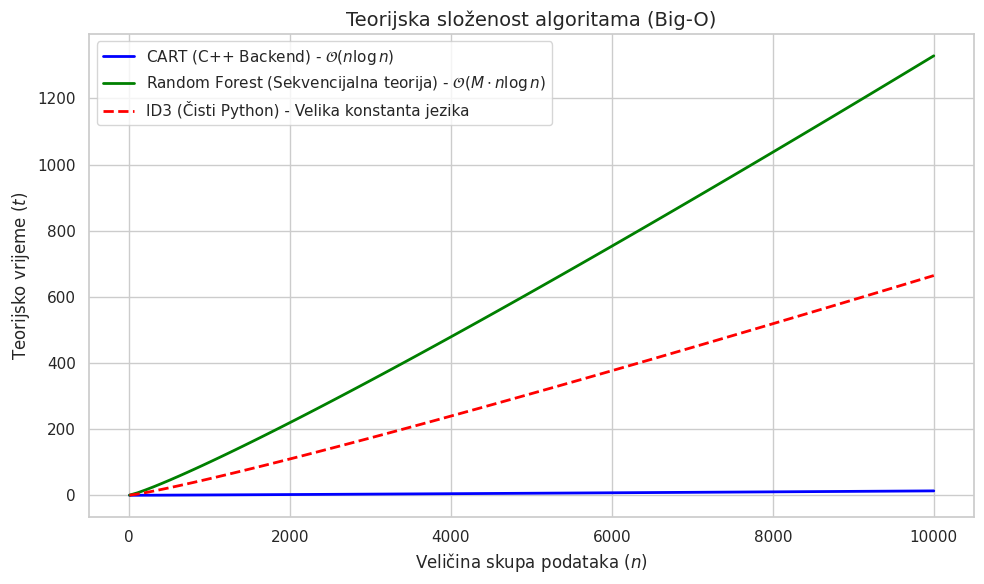

In [11]:
import numpy as np
import matplotlib.pyplot as plt

# Generiramo raspon veličine podataka (n)
n = np.linspace(10, 10000, 100)
M = 100 # Broj stabala u ansamblu
C_python = 50 # Konstanta sporosti za čisti Python (Chefboost)

# Teorijske funkcije vremena (Skalirane za vizualizaciju)
time_cart = n * np.log2(n) / 10000                # O(n log n)
time_rf = (M * n * np.log2(n)) / 10000            # O(M * n log n)
time_chefboost = C_python * (n * np.log2(n)) / 10000 # O(n log n) ali s ogromnom konstantom jezika

plt.figure(figsize=(10, 6))
plt.plot(n, time_cart, label='CART (C++ Backend) - $\mathcal{O}(n \log n)$', color='blue', linewidth=2)
plt.plot(n, time_rf, label='Random Forest (Sekvencijalna teorija) - $\mathcal{O}(M \cdot n \log n)$', color='green', linewidth=2)
plt.plot(n, time_chefboost, label='ID3 (Čisti Python) - Velika konstanta jezika', color='red', linestyle='dashed', linewidth=2)

plt.title('Teorijska složenost algoritama (Big-O)', fontsize=14)
plt.xlabel('Veličina skupa podataka ($n$)', fontsize=12)
plt.ylabel('Teorijsko vrijeme ($t$)', fontsize=12)
plt.legend()
plt.grid(True)
plt.tight_layout()

# SPREMANJE
plot_path_theory = os.path.join(results_path, 'teorijska_slozenost_graf.png')
plt.savefig(plot_path_theory, dpi=300)
plt.show()

# <a id="iris"></a>1. Analiza skupa podataka: Iris

## 1.1 Klasifikacija

### Priprema podatka

In [12]:
# --- 1. PRIPREMA PODATAKA ---
X_iris = df_iris.drop('species', axis=1)
y_iris_raw = df_iris['species']
le_iris = LabelEncoder()
y_iris = le_iris.fit_transform(y_iris_raw)

### EDA


Generiranje i spremanje eksplorativnih grafova (EDA)...


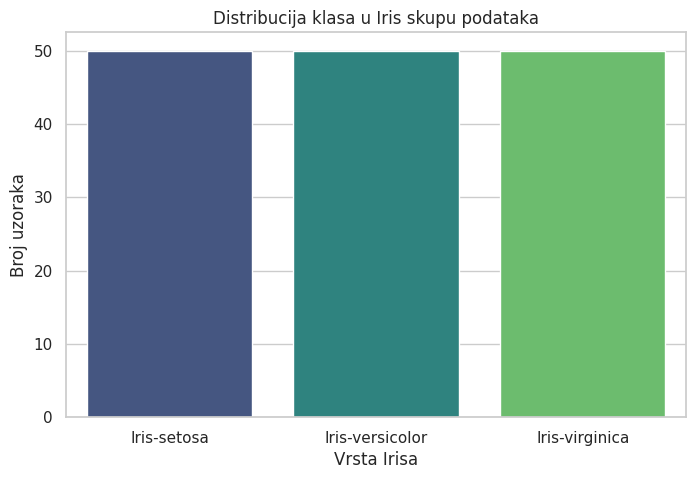

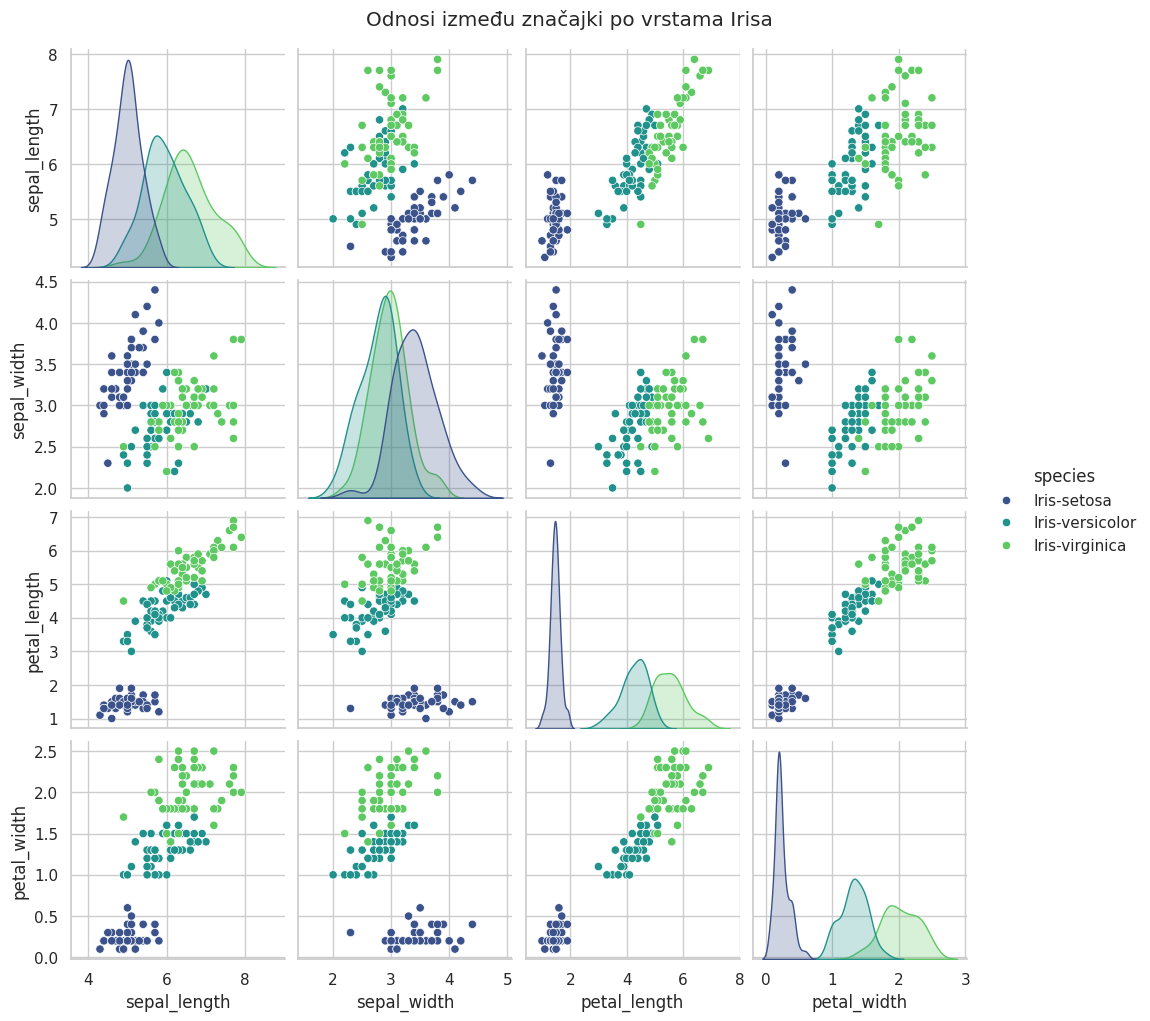

In [13]:
# --- 2. VIZUALIZACIJA CILJNE VARIJABLE I ODNOSA (Uz spremanje) ---
print("\nGeneriranje i spremanje eksplorativnih grafova (EDA)...")

# A) Distribucija klasa
plt.figure(figsize=(8, 5))
sns.countplot(x=y_iris_raw, palette='viridis')
plt.title('Distribucija klasa u Iris skupu podataka')
plt.ylabel('Broj uzoraka'); plt.xlabel('Vrsta Irisa')
plot_path_dist = os.path.join(results_path, 'iris_01_distribucija.png')
plt.savefig(plot_path_dist, dpi=300, bbox_inches='tight')
plt.show()

# B) Pairplot
pairplot_fig = sns.pairplot(df_iris, hue='species', height=2.5, palette='viridis')
pairplot_fig.fig.suptitle('Odnosi između značajki po vrstama Irisa', y=1.02)
plot_path_pair = os.path.join(results_path, 'iris_02_pairplot.png')
pairplot_fig.savefig(plot_path_pair, dpi=300, bbox_inches='tight')
plt.show()

### Pipeline benchmarking scikit-learn modeli

In [14]:
# Definicija K-Fold strategije (10 presjeka) ---
kf = KFold(n_splits=10, shuffle=True, random_state=42)

classifiers_skl = {
    "CART (Entropy)": DecisionTreeClassifier(criterion='entropy', random_state=42),
    "CART (Gini)": DecisionTreeClassifier(criterion='gini', random_state=42),
    "Random Forest (CPU)": RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    "XGBoost (CPU)": xgb.XGBClassifier(tree_method='hist', device='cpu', eval_metric='mlogloss', random_state=42),
    "XGBoost (GPU)": xgb.XGBClassifier(tree_method='hist', device='cuda', eval_metric='mlogloss', random_state=42)
}


results_cv = []

for name, clf in classifiers_skl.items():
    print(f"   Analiziram: {name}...")
    pipeline = Pipeline([('scaler', StandardScaler()), ('classifier', clf)])

    start_time = time.time()
    cv_scores = cross_validate(pipeline, X_iris, y_iris, cv=kf, scoring=['accuracy', 'f1_weighted'], n_jobs=1)
    end_time = time.time()

    results_cv.append({
        'Model': name,
        'Accuracy (CV)': cv_scores['test_accuracy'].mean(),
        'F1-Score (CV)': cv_scores['test_f1_weighted'].mean(),
        'Vrijeme (s)': end_time - start_time
    })
    del pipeline, cv_scores
    gc.collect()

print("Scikit-Learn modeli završeni. Podaci su u memoriji.")


Pokretanje Benchmarkinga (Scikit-Learn optimizirani modeli)...
   Analiziram: CART (Entropy)...
   Analiziram: CART (Gini)...
   Analiziram: Random Forest (CPU)...
   Analiziram: XGBoost (CPU)...
   Analiziram: XGBoost (GPU)...
Scikit-Learn modeli završeni. Podaci su u memoriji.


### Pipeline benchmarking chefboost modela originalni ID3 i C4.5

In [15]:
# ==============================================================================
# 4. GLAVNI BENCHMARKING (CHEFBOOST: Izvorni ID3 i C4.5)
# ==============================================================================
print("\n Pokretanje Benchmarkinga (Chefboost izvorni algoritmi - ovo može potrajati!)...")

# Chefboost zahtijeva DataFrame s ciljnom varijablom 'Decision' na kraju
df_chef = df_iris.copy()
df_chef.rename(columns={'species': 'Decision'}, inplace=True)

chef_models = ['ID3', 'C4.5']

for algo in chef_models:
    print(f"   Analiziram: {algo}...")
    config = {'algorithm': algo, 'enableParallelism': False}
    fold_acc, fold_f1 = [], []

    start_time = time.time()

    # Ručna K-Fold petlja koja koristi istu 'kf' podjelu kao i Scikit-Learn
    for train_idx, test_idx in kf.split(df_chef):
        train_df = df_chef.iloc[train_idx]
        test_df = df_chef.iloc[test_idx]

        # Utišavanje Chefboost logova da ne zaguše ekran
        import logging
        logging.getLogger("chefboost").setLevel(logging.WARNING)

        # Treniranje i predikcija
        model = chef.fit(train_df.copy(), config=config, target_label='Decision')
        y_pred = [chef.predict(model, row) for _, row in test_df.iterrows()]
        y_true = test_df['Decision'].values

        fold_acc.append(accuracy_score(y_true, y_pred))
        fold_f1.append(f1_score(y_true, y_pred, average='weighted'))

    end_time = time.time()

    # Dodajemo rezultate u ZAJEDNIČKU listu
    results_cv.append({
        'Model': f"Chefboost ({algo})",
        'Accuracy (CV)': np.mean(fold_acc),
        'F1-Score (CV)': np.mean(fold_f1),
        'Vrijeme (s)': end_time - start_time
    })
    gc.collect()

print("Chefboost modeli završeni. Svi podaci su spremni za prikaz.")


 Pokretanje Benchmarkinga (Chefboost izvorni algoritmi - ovo može potrajati!)...
   Analiziram: ID3...
26-04-07 15:50:05 - ID3 tree is going to be built...
26-04-07 15:50:06 - -------------------------
26-04-07 15:50:06 - finished in 1.6712677478790283 seconds
26-04-07 15:50:06 - -------------------------
26-04-07 15:50:06 - Evaluate train set
26-04-07 15:50:06 - -------------------------
26-04-07 15:50:06 - Accuracy: 97.03703703703704% on 135 instances
26-04-07 15:50:06 - Labels: ['Iris-setosa' 'Iris-versicolor' 'Iris-virginica']
26-04-07 15:50:06 - Confusion matrix: [[44, 0, 0], [0, 44, 4], [0, 0, 43]]
26-04-07 15:50:06 - Decision Iris-setosa
26-04-07 15:50:06 - Accuracy: 100.0
26-04-07 15:50:06 - Precision: 100.0%, Recall: 100.0%, F1: 100.0%
26-04-07 15:50:06 - Decision Iris-versicolor
26-04-07 15:50:06 - Accuracy: 97.037
26-04-07 15:50:06 - Precision: 91.6667%, Recall: 100.0%, F1: 95.6522%
26-04-07 15:50:06 - Decision Iris-virginica
26-04-07 15:50:06 - Accuracy: 97.037
26-04-07 15

### Vizualizacija jednog stabla odlučivanja i pravila


Generiram i spremam vizualizaciju CART stabla...


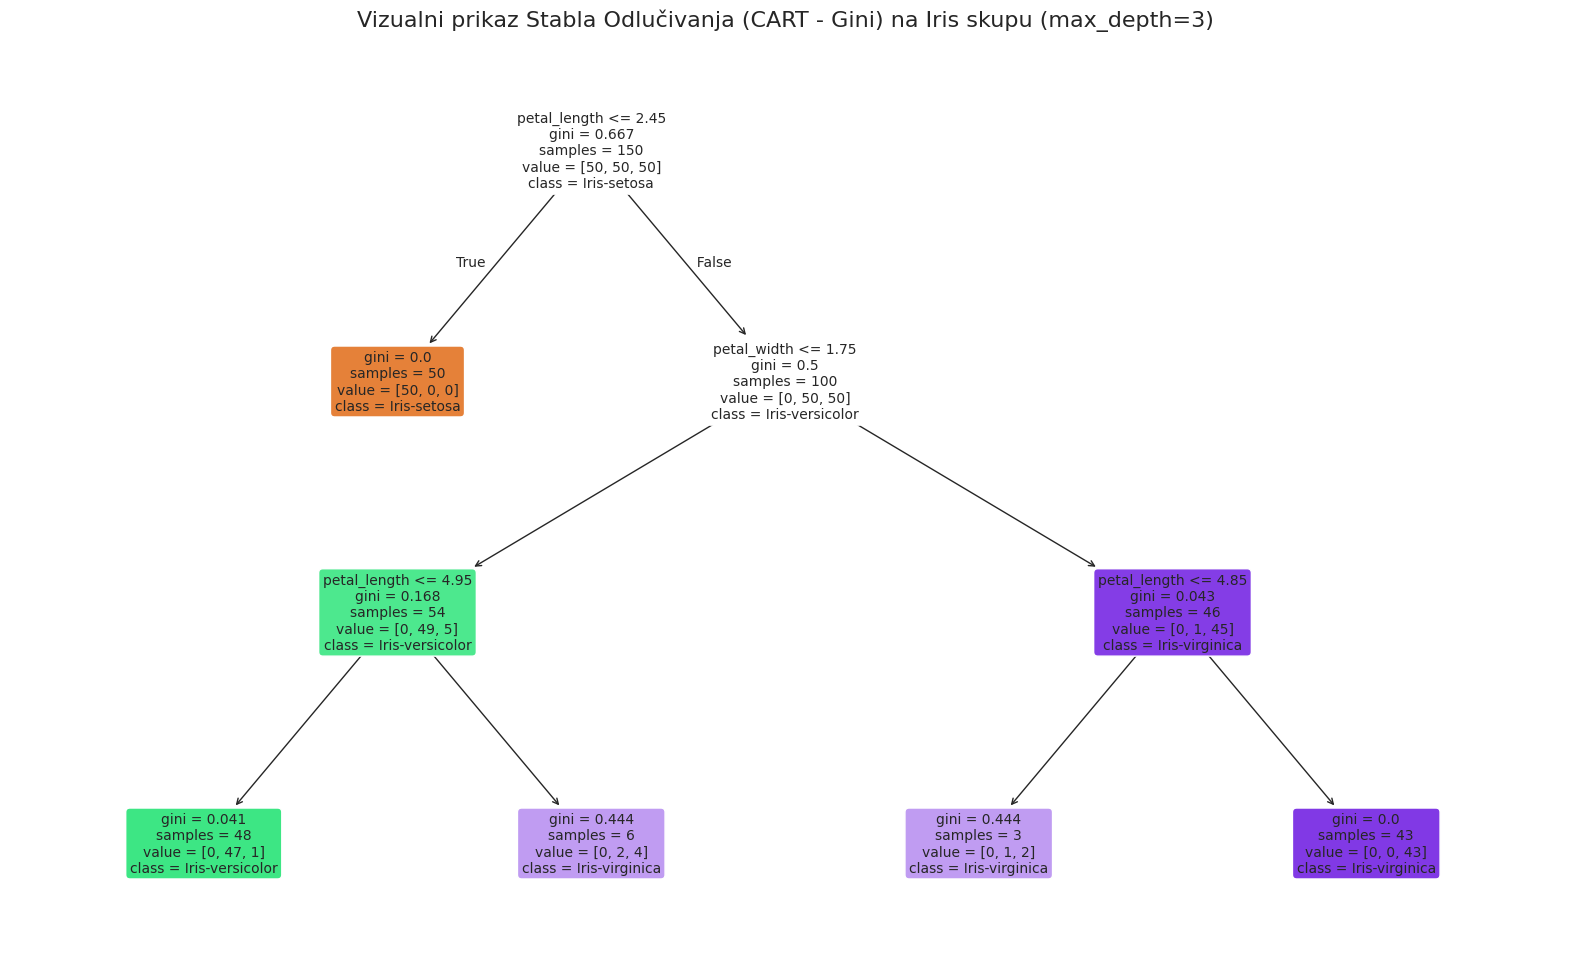

In [16]:
# --- VIZUALIZACIJA JEDNOG STABLA ODLUČIVANJA ---
print("\nGeneriram i spremam vizualizaciju CART stabla...")
viz_tree = DecisionTreeClassifier(criterion='gini', max_depth=3, random_state=42)
viz_tree.fit(X_iris, y_iris) # Treniramo samo za vizualizaciju

plt.figure(figsize=(20, 12))
from sklearn.tree import plot_tree
plot_tree(viz_tree, filled=True, feature_names=X_iris.columns.tolist(),
          class_names=le_iris.classes_.tolist(), rounded=True, fontsize=10)
plt.title("Vizualni prikaz Stabla Odlučivanja (CART - Gini) na Iris skupu (max_depth=3)", fontsize=16)

plot_path_tree = os.path.join(results_path, 'iris_02b_vizualizacija_stabla.png')
plt.savefig(plot_path_tree, dpi=300, bbox_inches='tight')
plt.show()

In [17]:
# ==============================================================================
# VIZUALIZACIJA CHEFBOOST PRAVILA (ID3 vs C4.5 arhitektura)
# ==============================================================================
import os

print("\n" + "="*50)
print("IZVLAČENJE STRUKTURE STABALA (CHEFBOOST PRAVILA)")
print("="*50)

# Chefboost očekuje da se ciljna varijabla doslovno zove 'Decision'
df_chef = df_iris.copy()
df_chef.rename(columns={'species': 'Decision'}, inplace=True)

# --- 1. Generiranje i ispis ID3 stabla ---
print("\n Gradim finalno ID3 stablo za vizualizaciju pravila...")
config_id3 = {'algorithm': 'ID3'}
# Isključujemo paralelizam za čišći ispis u konzoli
config_id3['enableParallelism'] = False
model_id3 = chef.fit(df_chef, config=config_id3)

print("\n" + "-"*40)
print("IZVORNI KOD ID3 STABLA (PRAVILA ODLUČIVANJA)")
print("-"*40)
# Chefboost automatski sprema pravila u ovu datoteku
with open("outputs/rules/rules.py", "r") as file:
    id3_rules = file.read()
    print(id3_rules)

# --- 2. Generiranje i ispis C4.5 stabla ---
print("\n🌲 Gradim finalno C4.5 stablo za vizualizaciju pravila...")
config_c45 = {'algorithm': 'C4.5'}
config_c45['enableParallelism'] = False
model_c45 = chef.fit(df_chef, config=config_c45)

print("\n" + "-"*40)
print("IZVORNI KOD C4.5 STABLA (PRAVILA ODLUČIVANJA)")
print("-"*40)
with open("outputs/rules/rules.py", "r") as file:
    c45_rules = file.read()
    print(c45_rules)

print("\n Pravila su uspješno izvučena")


IZVLAČENJE STRUKTURE STABALA (CHEFBOOST PRAVILA)

 Gradim finalno ID3 stablo za vizualizaciju pravila...
26-04-07 15:50:42 - ID3 tree is going to be built...
26-04-07 15:50:44 - -------------------------
26-04-07 15:50:44 - finished in 2.18509578704834 seconds
26-04-07 15:50:44 - -------------------------
26-04-07 15:50:44 - Evaluate train set
26-04-07 15:50:44 - -------------------------
26-04-07 15:50:44 - Accuracy: 97.33333333333333% on 150 instances
26-04-07 15:50:44 - Labels: ['Iris-setosa' 'Iris-versicolor' 'Iris-virginica']
26-04-07 15:50:44 - Confusion matrix: [[50, 0, 0], [0, 50, 4], [0, 0, 46]]
26-04-07 15:50:44 - Decision Iris-setosa
26-04-07 15:50:44 - Accuracy: 100.0
26-04-07 15:50:44 - Precision: 100.0%, Recall: 100.0%, F1: 100.0%
26-04-07 15:50:44 - Decision Iris-versicolor
26-04-07 15:50:44 - Accuracy: 97.3333
26-04-07 15:50:44 - Precision: 92.5926%, Recall: 100.0%, F1: 96.1539%
26-04-07 15:50:44 - Decision Iris-virginica
26-04-07 15:50:44 - Accuracy: 97.3333
26-04-07 

### Spremanje rezultata u CSV datotku

In [18]:
# ==============================================================================
# SPREMANJE REZULTATA U CSV
# ==============================================================================
print("\n Spremanje konačnih rezultata...")
df_res_iris = pd.DataFrame(results_cv)
csv_cv_path = os.path.join(results_path, 'iris_02_rezultati_cv_svi_modeli.csv')
df_res_iris.to_csv(csv_cv_path, index=False)
display(df_res_iris.sort_values(by='F1-Score (CV)', ascending=False))




 Spremanje konačnih rezultata...


,Model,Accuracy (CV),F1-Score (CV),Vrijeme (s)
2,Random Forest (CPU),0.960000,0.960219,4.209213
4,XGBoost (GPU),0.946667,0.945760,1.816794
0,CART (Entropy),0.940000,0.940219,0.257861
1,CART (Gini),0.940000,0.940219,0.143631
3,XGBoost (CPU),0.940000,0.939026,2.606942
5,Chefboost (ID3),0.933333,0.933347,17.650879
6,Chefboost (C4.5),0.933333,0.933347,17.640680


### Grafička usporedba performansi


 Generiranje grafičke usporedbe performansi...


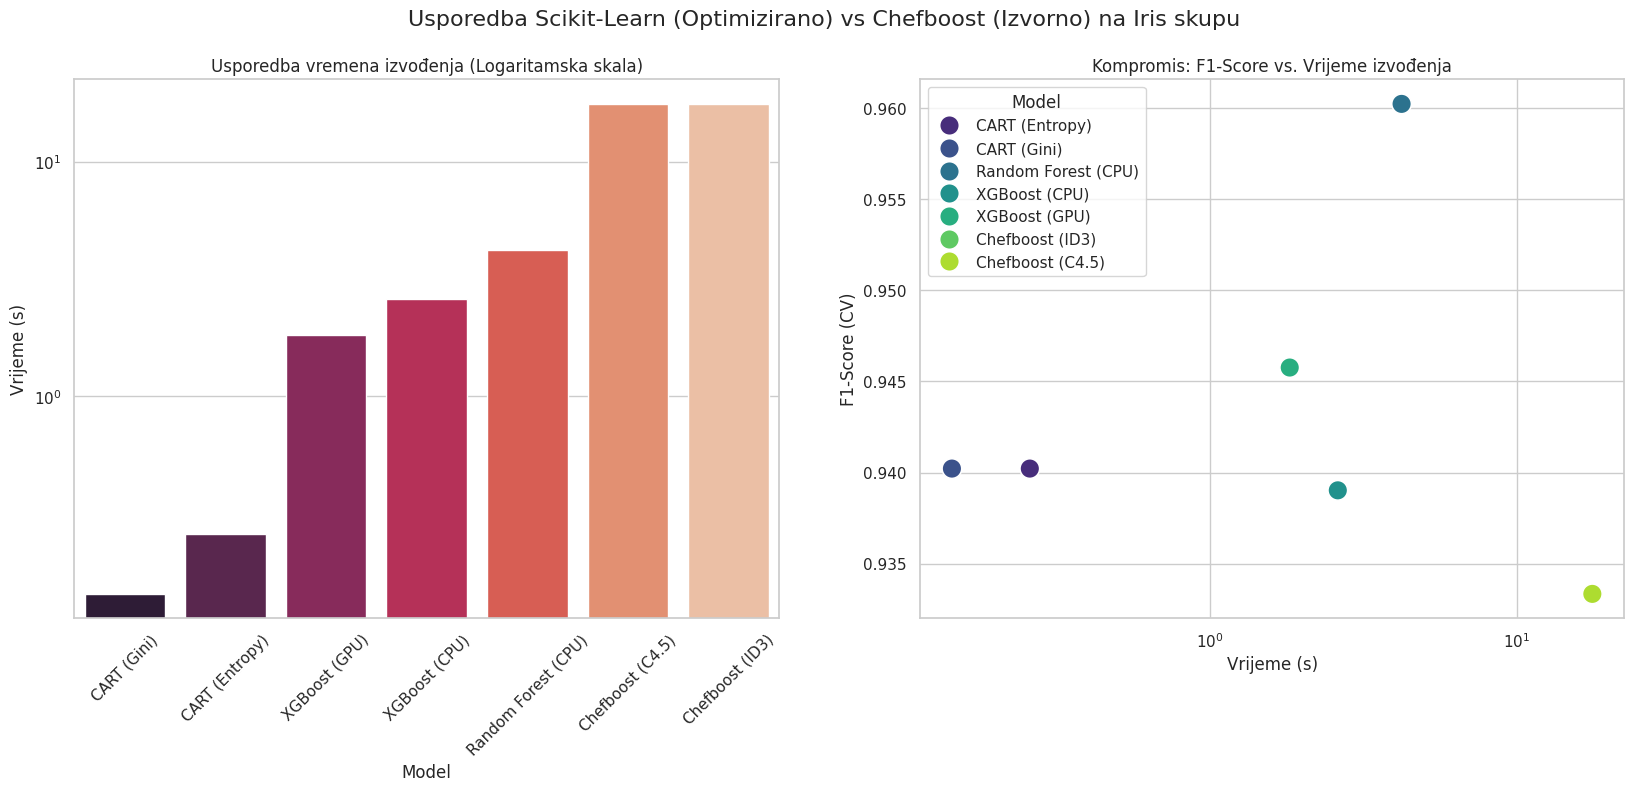


 SVE SPREMLJENO U: /content/drive/MyDrive/diplomski_rad_podaci/rezultati_eksperimenta


In [19]:
# ==============================================================================
# GRAFIČKA USPOREDBA (S LOGARITAMSKOM SKALOM)
# ==============================================================================
print("\n Generiranje grafičke usporedbe performansi...")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 7))
fig.suptitle('Usporedba Scikit-Learn (Optimizirano) vs Chefboost (Izvorno) na Iris skupu', fontsize=16)

# A) Stupčasti dijagram vremena izvođenja
sns.barplot(x='Model', y='Vrijeme (s)', data=df_res_iris.sort_values('Vrijeme (s)'), ax=ax1, palette='rocket')
ax1.set_title('Usporedba vremena izvođenja (Logaritamska skala)')
ax1.tick_params(axis='x', rotation=45)
ax1.set_yscale("log") # KLJUČNO ZA DIPLOMSKI: Prikazuje razliku između sekundi i milisekundi

# B) Scatter plot (Kompromis Vrijeme vs Performanse)
sns.scatterplot(data=df_res_iris, x='Vrijeme (s)', y='F1-Score (CV)', hue='Model', s=200, ax=ax2, palette='viridis')
ax2.set_title('Kompromis: F1-Score vs. Vrijeme izvođenja')
ax2.set_xscale("log") # Log skala i za x-os na scatter plotu

# Spremanje grafa
plot_path_perf = os.path.join(results_path, 'iris_03_performanse_vrijeme_log.png')
plt.savefig(plot_path_perf, dpi=300, bbox_inches='tight')
plt.show()

print(f"\n SVE SPREMLJENO U: {results_path}")

# <a id="bank"></a>2. Analiza skupa podataka: Bank Marketing

## 2.1 Klasifikacija

### Priprema podataka

In [20]:
# --- 1. PRIPREMA PODATAKA ---
print("Pripremanje podatke (uklanjanje 'duration' zbog curenja podataka)...")
df_bank_prep = df_bank.drop('duration', axis=1)

X_bank = df_bank_prep.drop('y', axis=1)
y_bank_raw = df_bank_prep['y']
le_bank = LabelEncoder()
y_bank = le_bank.fit_transform(y_bank_raw)

# Definiranje stupaca za Pipeline
numeric_features = X_bank.select_dtypes(include=np.number).columns.tolist()
categorical_features = X_bank.select_dtypes(include=['object']).columns.tolist()

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

# Izračun težine za XGBoost zbog neuravnoteženosti klasa
scale_weight = sum(y_bank == 0) / sum(y_bank == 1)

Pripremanje podatke (uklanjanje 'duration' zbog curenja podataka)...


### EDA

In [21]:
# --- 2. VIZUALIZACIJA (EDA) ---
print("\nGeneriranje i spremanje grafa distribucije klasa...")
plt.figure(figsize=(8, 5))
sns.countplot(x=y_bank_raw, palette='viridis')
plt.title('Distribucija klasa u Bank Marketing skupu (Vrlo neuravnoteženo)')
plot_path_bank_dist = os.path.join(results_path, 'bank_clf_01_distribucija.png')
plt.savefig(plot_path_bank_dist, dpi=300, bbox_inches='tight')
plt.close()



Generiranje i spremanje grafa distribucije klasa...


### Pipeline benchmarking CPU vs GPU modela

In [22]:
# --- 3. GLAVNI BENCHMARKING (CPU vs GPU) ---
print("\n  Pokretanje Benchmarkinga (10-Fold CV)...")
kf_bank = KFold(n_splits=10, shuffle=True, random_state=42)

classifiers_bank = {
    "CART (Entropy)": DecisionTreeClassifier(criterion='entropy', random_state=42, class_weight='balanced'),
    "CART (Gini)": DecisionTreeClassifier(criterion='gini', random_state=42, class_weight='balanced'),
    "Random Forest (CPU)": RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced', n_jobs=-1),
    "XGBoost (CPU)": xgb.XGBClassifier(tree_method='hist', device='cpu', eval_metric='logloss', scale_pos_weight=scale_weight, random_state=42),
    "XGBoost (GPU)": xgb.XGBClassifier(tree_method='hist', device='cuda', eval_metric='logloss', scale_pos_weight=scale_weight, random_state=42)
}

results_cv_bank = []

for name, clf in classifiers_bank.items():
    print(f"   Analiziram: {name}...")
    pipeline = Pipeline([('preprocessor', preprocessor), ('classifier', clf)])

    start_time = time.time()

    try:
        # Mjerimo ROC AUC i F1 za neuravnotežene klase
        cv_scores = cross_validate(pipeline, X_bank, y_bank, cv=kf_bank, scoring=['roc_auc', 'f1_weighted'], n_jobs=1)
        end_time = time.time()

        results_cv_bank.append({
            'Model': name,
            'ROC AUC (CV)': cv_scores['test_roc_auc'].mean(),
            'F1-Score (CV)': cv_scores['test_f1_weighted'].mean(),
            'Vrijeme (s)': end_time - start_time
        })
    except Exception as e:
        print(f"    Greška pri izvođenju {name}: {e}")
        print("   (Ako XGBoost GPU javi grešku, to znači da runtime nema aktiviranu grafičku karticu).")

    del pipeline
    if 'cv_scores' in locals(): del cv_scores
    gc.collect()



  Pokretanje Benchmarkinga (10-Fold CV)...
   Analiziram: CART (Entropy)...
   Analiziram: CART (Gini)...
   Analiziram: Random Forest (CPU)...
   Analiziram: XGBoost (CPU)...
   Analiziram: XGBoost (GPU)...


### Spremanje rezultata u CSV datoteku

In [23]:
# --- 4. SPREMANJE REZULTATA ---
print("\nSpremanje konačnih rezultata...")
df_res_bank = pd.DataFrame(results_cv_bank)
csv_bank_path = os.path.join(results_path, 'bank_clf_02_rezultati_cv.csv')
df_res_bank.to_csv(csv_bank_path, index=False)
display(df_res_bank.sort_values(by='ROC AUC (CV)', ascending=False))



Spremanje konačnih rezultata...


,Model,ROC AUC (CV),F1-Score (CV),Vrijeme (s)
2,Random Forest (CPU),0.782553,0.869738,54.215019
4,XGBoost (GPU),0.781890,0.844912,7.281504
3,XGBoost (CPU),0.779433,0.844065,11.860145
1,CART (Gini),0.611120,0.838609,8.179480
0,CART (Entropy),0.611006,0.838132,7.198496


### Grafička usporedba performansi


Generiranje grafičke usporedbe performansi...


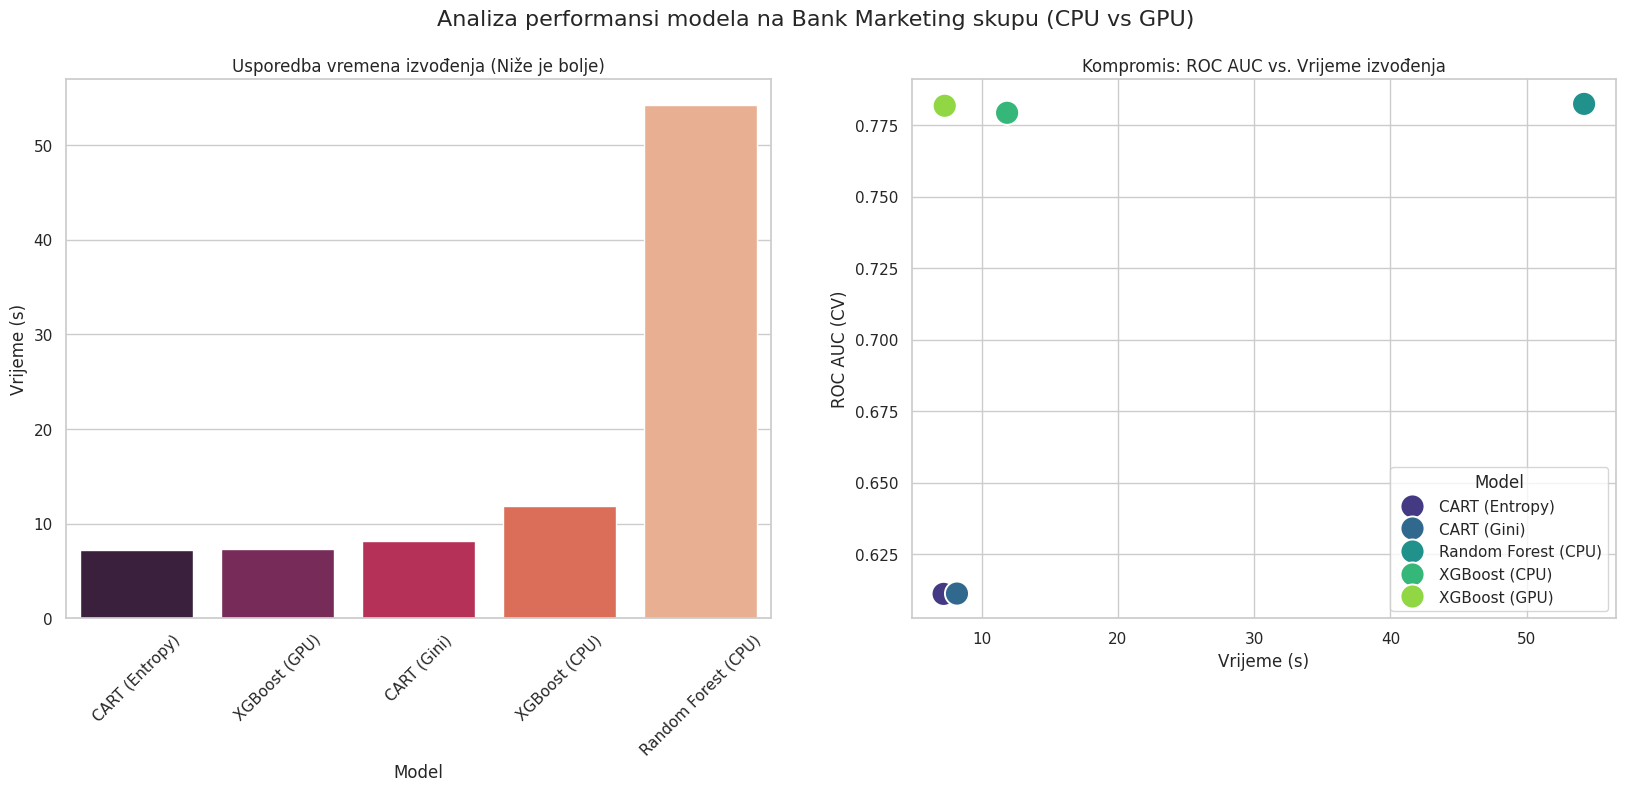


 BANK MARKETING (KLASIFIKACIJA) ZAVRŠEN. SPREMLJENO U: /content/drive/MyDrive/diplomski_rad_podaci/rezultati_eksperimenta


In [24]:
# --- 5. GRAFIČKA USPOREDBA ---
print("\nGeneriranje grafičke usporedbe performansi...")
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 7))
fig.suptitle('Analiza performansi modela na Bank Marketing skupu (CPU vs GPU)', fontsize=16)

# A) Stupčasti dijagram (Vrijeme)
sns.barplot(x='Model', y='Vrijeme (s)', data=df_res_bank.sort_values('Vrijeme (s)'), ax=ax1, palette='rocket')
ax1.set_title('Usporedba vremena izvođenja (Niže je bolje)')
ax1.tick_params(axis='x', rotation=45)

# B) Scatter plot (Vrijeme vs ROC AUC)
sns.scatterplot(data=df_res_bank, x='Vrijeme (s)', y='ROC AUC (CV)', hue='Model', s=300, ax=ax2, palette='viridis')
ax2.set_title('Kompromis: ROC AUC vs. Vrijeme izvođenja')

plot_path_bank_perf = os.path.join(results_path, 'bank_clf_03_performanse_vrijeme.png')
plt.savefig(plot_path_bank_perf, dpi=300, bbox_inches='tight')
plt.show()

print(f"\n BANK MARKETING (KLASIFIKACIJA) ZAVRŠEN. SPREMLJENO U: {results_path}")

## 2.2 Regresija

### Priprema podataka

In [25]:
# --- 1. PRIPREMA PODATAKA ---
X_bank_reg = df_bank.drop(['age', 'duration'], axis=1)
y_bank_reg = df_bank['age']

numeric_features_reg = X_bank_reg.select_dtypes(include=np.number).columns.tolist()
categorical_features_reg = X_bank_reg.select_dtypes(include=['object']).columns.tolist()

preprocessor_bank_reg = ColumnTransformer(
    transformers=[
        ('num', Pipeline([('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler())]), numeric_features_reg),
        ('cat', Pipeline([('imputer', SimpleImputer(strategy='most_frequent')), ('onehot', OneHotEncoder(handle_unknown='ignore'))]), categorical_features_reg)
    ])

### EDA

In [26]:
# --- 2. VIZUALIZACIJA CILJNE VARIJABLE ---
plt.figure(figsize=(10, 5))
sns.histplot(y_bank_reg, kde=True, bins=30, color='teal')
plt.title('Distribucija dobi klijenata (Ciljna varijabla regresije)')
plt.xlabel('Dob'); plt.ylabel('Broj klijenata')
plot_path_reg_dist = os.path.join(results_path, 'bank_reg_01_distribucija.png')
plt.savefig(plot_path_reg_dist, dpi=300, bbox_inches='tight')
plt.close()


### Pipeline benchmarking  CPU vs GPU modela

In [27]:
# --- 3. GLAVNI BENCHMARKING (CPU vs GPU) ---
print("\n  Pokretanje Benchmarkinga Regresije (10-Fold CV)...")
kf_reg = KFold(n_splits=10, shuffle=True, random_state=42)
scoring_reg = {'neg_rmse': 'neg_root_mean_squared_error', 'r2': 'r2'}

# ISPRAVAK: n_jobs=-1 ide SAMO u modele. U cross_validate ide n_jobs=1.
regressors = {
    "CART Regressor": DecisionTreeRegressor(random_state=42),
    "Random Forest Regressor (CPU)": RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    "XGBoost Regressor (CPU)": xgb.XGBRegressor(objective='reg:squarederror', tree_method='hist', device='cpu', random_state=42),
    "XGBoost Regressor (GPU)": xgb.XGBRegressor(objective='reg:squarederror', tree_method='hist', device='cuda', random_state=42)
}

results_cv_bank_reg = []

for name, reg in regressors.items():
    print(f"   Analiziram: {name}...")
    pipeline = Pipeline([('preprocessor', preprocessor_bank_reg), ('regressor', reg)])
    start_time = time.time()

    try:
        cv_scores = cross_validate(pipeline, X_bank_reg, y_bank_reg, cv=kf_reg, scoring=scoring_reg, n_jobs=1)
        end_time = time.time()

        results_cv_bank_reg.append({
            'Model': name,
            'RMSE (CV)': -cv_scores['test_neg_rmse'].mean(), # Vraćamo u pozitivnu vrijednost
            'R2 Score (CV)': cv_scores['test_r2'].mean(),
            'Vrijeme (s)': end_time - start_time
        })
    except Exception as e:
        print(f"    Greška pri izvođenju {name}: {e}")

    del pipeline
    if 'cv_scores' in locals(): del cv_scores
    gc.collect()





  Pokretanje Benchmarkinga Regresije (10-Fold CV)...
   Analiziram: CART Regressor...
   Analiziram: Random Forest Regressor (CPU)...
   Analiziram: XGBoost Regressor (CPU)...
   Analiziram: XGBoost Regressor (GPU)...


### Spremanje rezultata u CSV datoteku

In [28]:
# --- 4. SPREMANJE I VIZUALIZACIJA ---
df_res_bank_reg = pd.DataFrame(results_cv_bank_reg)
csv_bank_reg_path = os.path.join(results_path, 'bank_reg_02_rezultati_cv.csv')
df_res_bank_reg.to_csv(csv_bank_reg_path, index=False)
display(df_res_bank_reg.sort_values(by='RMSE (CV)', ascending=True))

,Model,RMSE (CV),R2 Score (CV),Vrijeme (s)
3,XGBoost Regressor (GPU),7.762831,0.465204,4.750692
2,XGBoost Regressor (CPU),7.762831,0.465204,7.914264
1,Random Forest Regressor (CPU),7.988819,0.433560,5095.856594
0,CART Regressor,10.963041,-0.066664,87.247251


### Grafička usporedba performansi

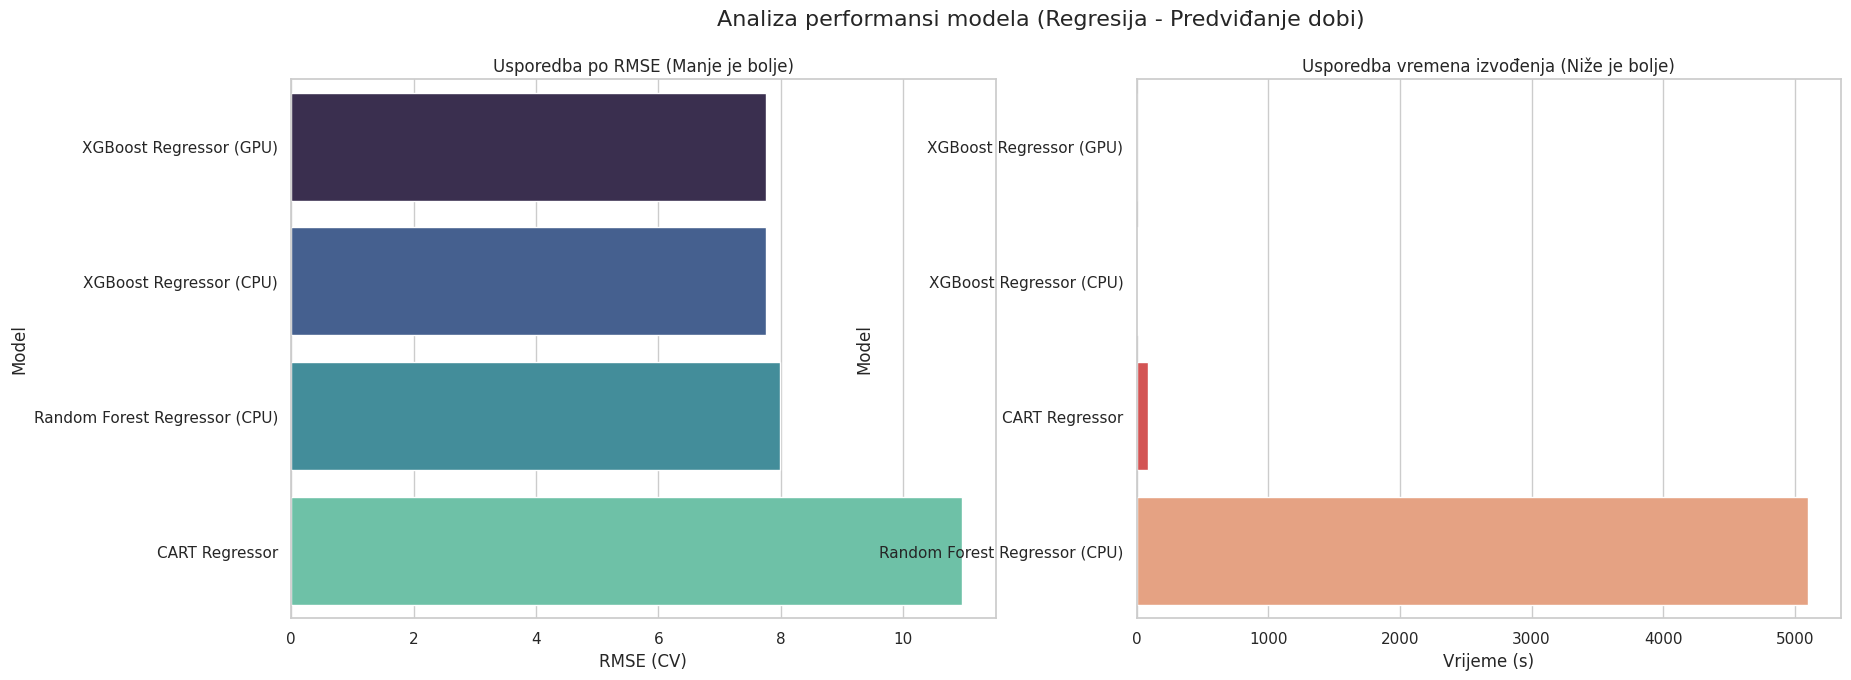

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(20, 7))
fig.suptitle('Analiza performansi modela (Regresija - Predviđanje dobi)', fontsize=16)

sns.barplot(x='RMSE (CV)', y='Model', data=df_res_bank_reg.sort_values('RMSE (CV)'), ax=axes[0], palette='mako')
axes[0].set_title('Usporedba po RMSE (Manje je bolje)')

sns.barplot(x='Vrijeme (s)', y='Model', data=df_res_bank_reg.sort_values('Vrijeme (s)'), ax=axes[1], palette='rocket')
axes[1].set_title('Usporedba vremena izvođenja (Niže je bolje)')

plot_path_reg_perf = os.path.join(results_path, 'bank_reg_03_performanse.png')
plt.savefig(plot_path_reg_perf, dpi=300, bbox_inches='tight')
plt.show()

## XAI Objašnjivost XGBoost modela (SHAP)

ZAPOČINJEM XAI ANALIZU POMOĆU SHAP-a
1. Treniram finalni XGBoost model na cijelom skupu...
2. Pripremam podatke za SHAP...
3. Računam SHAP vrijednosti (ovo može potrajati par minuta)...

4. Generiram i spremam SHAP Summary Plot...


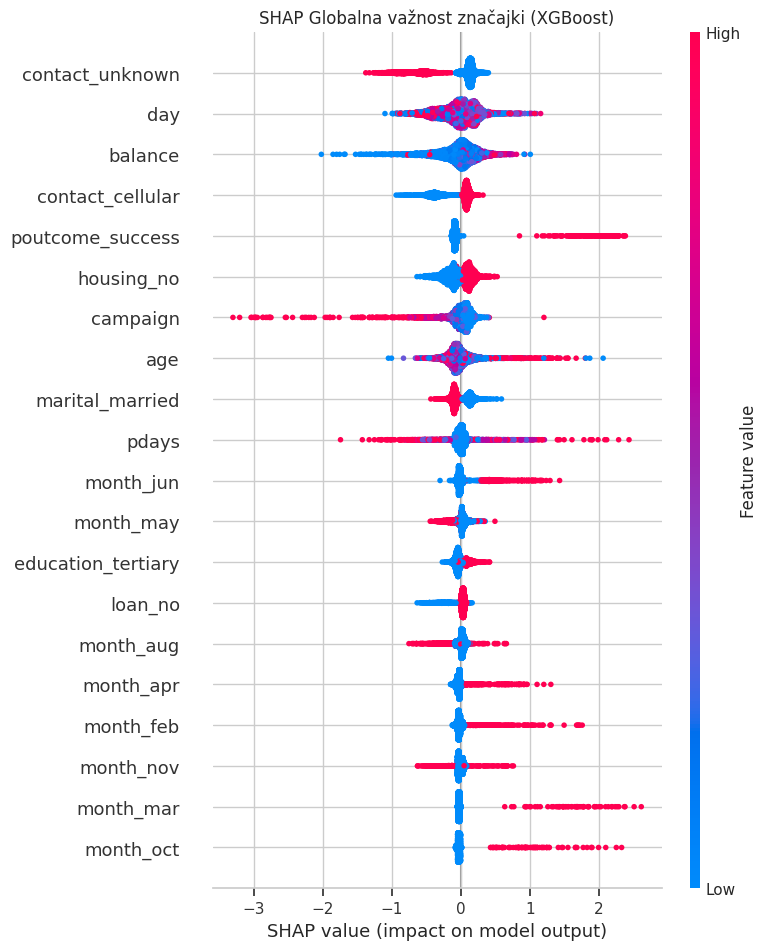

   SHAP slika spremljena u: /content/drive/MyDrive/diplomski_rad_podaci/rezultati_eksperimenta/bank_clf_04_shap_summary.png


In [30]:
print("ZAPOČINJEM XAI ANALIZU POMOĆU SHAP-a")
print("="*50)

import shap

# Treniramo finalni model (Koristimo CPU da osiguramo stabilnost SHAP-a)
print("1. Treniram finalni XGBoost model na cijelom skupu...")
final_xgb_model = xgb.XGBClassifier(eval_metric='logloss', random_state=42, tree_method='hist', device='cpu')
final_pipeline = Pipeline([('preprocessor', preprocessor), ('classifier', final_xgb_model)])
final_pipeline.fit(X_bank, y_bank)

print("2. Pripremam podatke za SHAP...")
X_bank_transformed = final_pipeline.named_steps['preprocessor'].transform(X_bank)
ohe_feature_names = final_pipeline.named_steps['preprocessor'].named_transformers_['cat'].named_steps['onehot'].get_feature_names_out(categorical_features)
all_feature_names = numeric_features + ohe_feature_names.tolist()
X_bank_transformed_df = pd.DataFrame(X_bank_transformed, columns=all_feature_names)

print("3. Računam SHAP vrijednosti (ovo može potrajati par minuta)...")
explainer = shap.TreeExplainer(final_pipeline.named_steps['classifier'])
# Računamo na podskupu od 5000 redaka da ne čekamo sat vremena!
shap_values = explainer.shap_values(X_bank_transformed_df.sample(5000, random_state=42))

print("\n4. Generiram i spremam SHAP Summary Plot...")
plt.figure(figsize=(10, 8))
# Važno: show=False omogućuje nam da spremimo graf prije nego nestane
shap.summary_plot(shap_values, X_bank_transformed_df.sample(5000, random_state=42), plot_type="dot", show=False)
plt.title("SHAP Globalna važnost značajki (XGBoost)")

plot_path_shap = os.path.join(results_path, 'bank_clf_04_shap_summary.png')
plt.savefig(plot_path_shap, dpi=300, bbox_inches='tight')
plt.show()

print(f"   SHAP slika spremljena u: {plot_path_shap}")

## 2.3 Empirijska krivulja učenja (10% - 100%)


In [31]:
# ==============================================================================
# EMPIRIJSKA SLOŽENOST (Rast vremena treniranja s povećanjem skupa)
# ==============================================================================
print("\n" + "="*50)
print("MJERENJE EMPIRIJSKE SLOŽENOSTI TRENIRANJA (10% -> 100% podataka)")
print("="*50)

# Definiramo udjele (10%, 30%, 50%, 75%, 100%)
proportions = [0.1, 0.3, 0.5, 0.75, 1.0]
empirical_times = {
    'CART (Entropy)': [],
    'Random Forest (CPU)': [],
    'XGBoost (CPU)': [],
    'XGBoost (GPU)': []
}
data_sizes = []

for prop in proportions:
    print(f"   Mjerenje na {int(prop*100)}% skupa podataka...")

    if prop < 1.0:
        X_sub, _, y_sub, _ = train_test_split(X_bank, y_bank, train_size=prop, random_state=42, stratify=y_bank)
    else:
        X_sub, y_sub = X_bank, y_bank

    data_sizes.append(len(X_sub))

    # Skaliranje podskupa kako bi uvjeti bili pošteni
    X_sub_prep = preprocessor.fit_transform(X_sub)

    for name in empirical_times.keys():
        # Izvlačimo modele iz rječnika za klasifikaciju
        clf = classifiers_bank[name]

        try:
            start_time = time.time()
            clf.fit(X_sub_prep, y_sub) # Mjerimo SAMO vrijeme treniranja!
            end_time = time.time()
            empirical_times[name].append(end_time - start_time)
        except Exception:
            # Ako GPU pukne, stavljamo null vrijednost
            empirical_times[name].append(None)

    gc.collect()




MJERENJE EMPIRIJSKE SLOŽENOSTI TRENIRANJA (10% -> 100% podataka)
   Mjerenje na 10% skupa podataka...
   Mjerenje na 30% skupa podataka...
   Mjerenje na 50% skupa podataka...
   Mjerenje na 75% skupa podataka...
   Mjerenje na 100% skupa podataka...


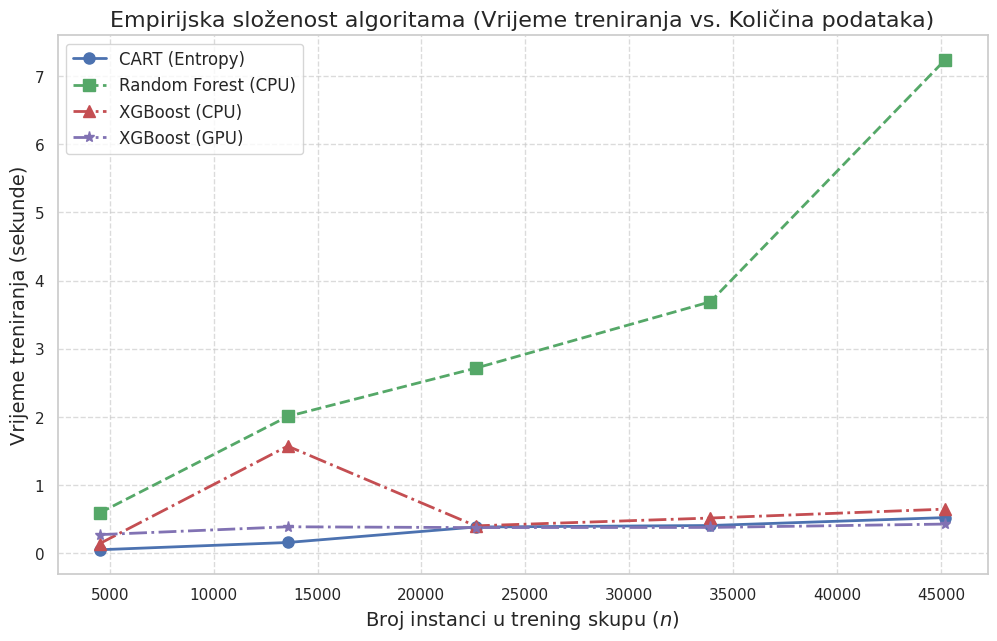


   Empirijski graf spremljen u: /content/drive/MyDrive/diplomski_rad_podaci/rezultati_eksperimenta/bank_clf_05_empirijska_slozenost.png


In [32]:
# --- VIZUALIZACIJA EMPIRIJSKE KRIVULJE ---
plt.figure(figsize=(12, 7))

# Definiramo boje i stilove za jasnoću
styles = {'CART (Entropy)': 'b-o', 'Random Forest (CPU)': 'g--s',
          'XGBoost (CPU)': 'r-.^', 'XGBoost (GPU)': 'm-.*'}

for name, times in empirical_times.items():
    if times[0] is not None: # Ako algoritam nije puknuo
        plt.plot(data_sizes, times, styles[name], label=name, markersize=8, linewidth=2)

plt.title('Empirijska složenost algoritama (Vrijeme treniranja vs. Količina podataka)', fontsize=16)
plt.xlabel('Broj instanci u trening skupu ($n$)', fontsize=14)
plt.ylabel('Vrijeme treniranja (sekunde)', fontsize=14)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)

plot_path_empirical = os.path.join(results_path, 'bank_clf_05_empirijska_slozenost.png')
plt.savefig(plot_path_empirical, dpi=300, bbox_inches='tight')
plt.show()

print(f"\n   Empirijski graf spremljen u: {plot_path_empirical}")

# <a id="adult"></a>3. Analiza skupa podataka: Adult

## 3.1 Klasifikacija

### Priprema podataka

In [33]:
# --- 1. PRIPREMA PODATAKA ---
df_adult_prep = df_adult.drop('fnlwgt', axis=1) # Uklanjamo fnlwgt

X_adult = df_adult_prep.drop('income', axis=1)
y_adult_raw = df_adult_prep['income']

le_adult = LabelEncoder()
y_adult = le_adult.fit_transform(y_adult_raw)

numeric_features_adult = X_adult.select_dtypes(include=np.number).columns.tolist()
categorical_features_adult = X_adult.select_dtypes(include=['object']).columns.tolist()

preprocessor_adult = ColumnTransformer(
    transformers=[
        ('num', Pipeline([('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler())]), numeric_features_adult),
        ('cat', Pipeline([('imputer', SimpleImputer(strategy='most_frequent')), ('onehot', OneHotEncoder(handle_unknown='ignore', drop='first'))]), categorical_features_adult)
    ])

scale_weight_adult = sum(y_adult == 0) / sum(y_adult == 1)

### EDA

In [34]:
# --- 2. VIZUALIZACIJA (EDA) ---
print("\nGeneriranje i spremanje grafa distribucije klasa...")
plt.figure(figsize=(8, 5))
sns.countplot(x=y_adult_raw, palette='viridis')
plt.title('Distribucija klasa u Adult skupu (Prihod)')
plot_path_adult_dist = os.path.join(results_path, 'adult_clf_01_distribucija.png')
plt.savefig(plot_path_adult_dist, dpi=300, bbox_inches='tight')
plt.close()



Generiranje i spremanje grafa distribucije klasa...


###  Pipeline benchmarking CPU vs GPU modela

In [35]:
# --- 3. GLAVNI BENCHMARKING (CPU vs GPU) ---
print("\n     Pokretanje Benchmarkinga Klasifikacije (10-Fold CV)...")
kf_adult = KFold(n_splits=10, shuffle=True, random_state=42)

classifiers_adult = {
    "CART (Entropy)": DecisionTreeClassifier(criterion='entropy', random_state=42, class_weight='balanced'),
    "CART (Gini)": DecisionTreeClassifier(criterion='gini', random_state=42, class_weight='balanced'),
    "Random Forest (CPU)": RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42, n_jobs=-1),
    "XGBoost (CPU)": xgb.XGBClassifier(tree_method='hist', device='cpu', eval_metric='logloss', scale_pos_weight=scale_weight_adult, random_state=42),
    "XGBoost (GPU)": xgb.XGBClassifier(tree_method='hist', device='cuda', eval_metric='logloss', scale_pos_weight=scale_weight_adult, random_state=42)
}

results_cv_adult = []

for name, clf in classifiers_adult.items():
    print(f"   Analiziram: {name}...")
    pipeline = Pipeline([('preprocessor', preprocessor_adult), ('classifier', clf)])
    start_time = time.time()

    try:
        cv_scores = cross_validate(pipeline, X_adult, y_adult, cv=kf_adult, scoring=['roc_auc', 'f1_weighted'], n_jobs=1) # Ovdje ide n_jobs=1
        end_time = time.time()

        results_cv_adult.append({
            'Model': name,
            'ROC AUC (CV)': cv_scores['test_roc_auc'].mean(),
            'F1-Score (CV)': cv_scores['test_f1_weighted'].mean(),
            'Vrijeme (s)': end_time - start_time
        })
    except Exception as e:
        print(f"     Greška pri izvođenju {name}: {e}")

    del pipeline
    if 'cv_scores' in locals(): del cv_scores
    gc.collect()



     Pokretanje Benchmarkinga Klasifikacije (10-Fold CV)...
   Analiziram: CART (Entropy)...
   Analiziram: CART (Gini)...
   Analiziram: Random Forest (CPU)...
   Analiziram: XGBoost (CPU)...
   Analiziram: XGBoost (GPU)...


### Spremanje rezultata u CSV datoteku

In [36]:
# --- 4. SPREMANJE REZULTATA ---
df_res_adult = pd.DataFrame(results_cv_adult)
csv_adult_path = os.path.join(results_path, 'adult_clf_02_rezultati_cv.csv')
df_res_adult.to_csv(csv_adult_path, index=False)
display(df_res_adult.sort_values(by='ROC AUC (CV)', ascending=False))


,Model,ROC AUC (CV),F1-Score (CV),Vrijeme (s)
4,XGBoost (GPU),0.927747,0.843573,3.961667
3,XGBoost (CPU),0.927736,0.843513,5.204721
2,Random Forest (CPU),0.890170,0.842833,248.770175
0,CART (Entropy),0.770694,0.816955,14.668582
1,CART (Gini),0.769002,0.815886,15.328915


:### Grafička usporedba performansi


Generiranje grafičke usporedbe performansi...


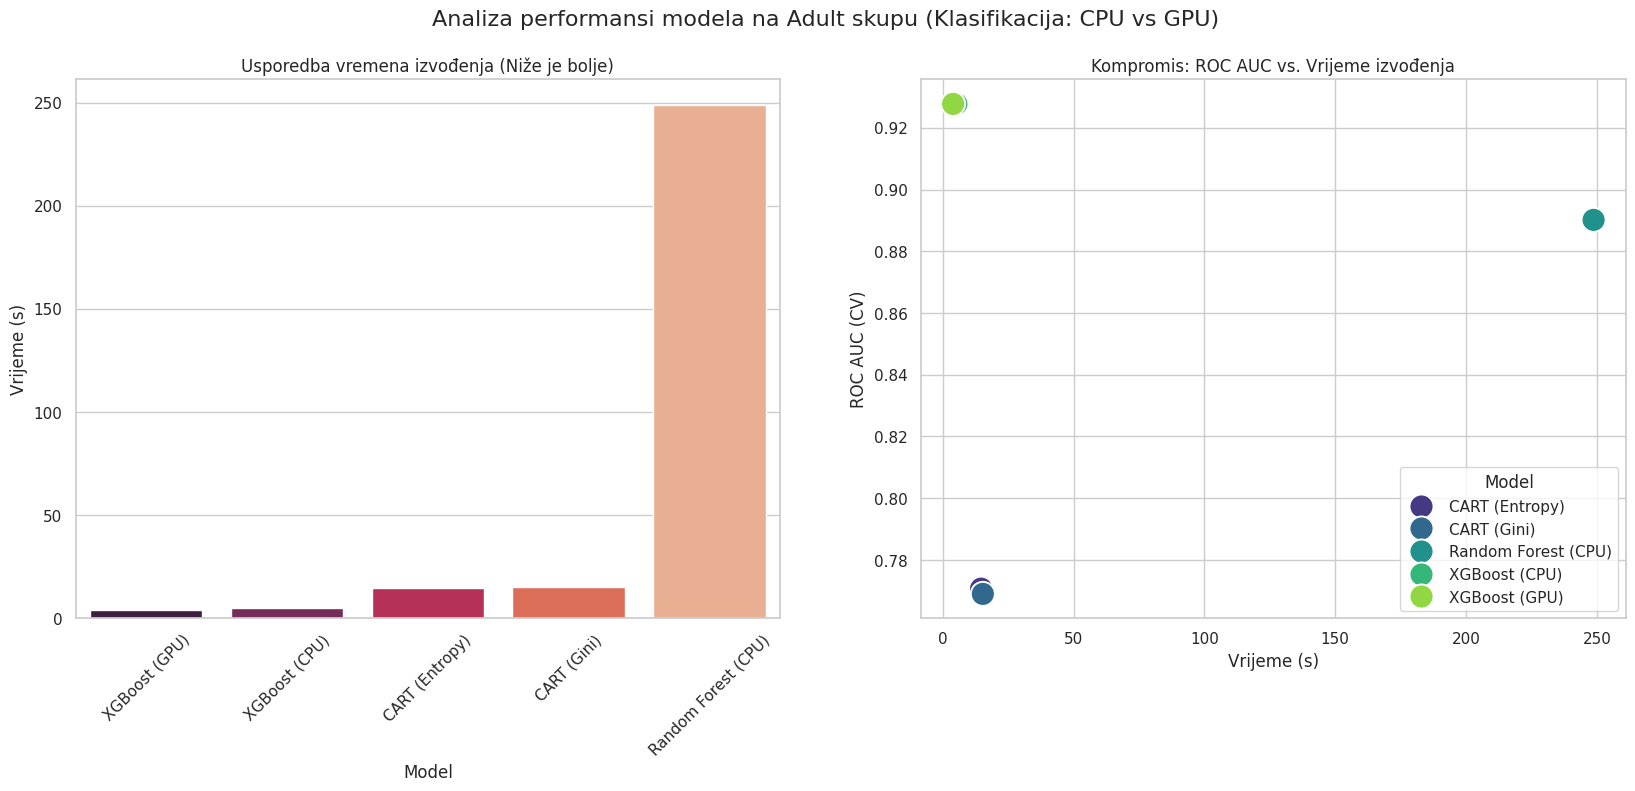

In [37]:
# --- 5. GRAFIČKA USPOREDBA ---
print("\nGeneriranje grafičke usporedbe performansi...")
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 7))
fig.suptitle('Analiza performansi modela na Adult skupu (Klasifikacija: CPU vs GPU)', fontsize=16)

sns.barplot(x='Model', y='Vrijeme (s)', data=df_res_adult.sort_values('Vrijeme (s)'), ax=ax1, palette='rocket')
ax1.set_title('Usporedba vremena izvođenja (Niže je bolje)')
ax1.tick_params(axis='x', rotation=45)

sns.scatterplot(data=df_res_adult, x='Vrijeme (s)', y='ROC AUC (CV)', hue='Model', s=300, ax=ax2, palette='viridis')
ax2.set_title('Kompromis: ROC AUC vs. Vrijeme izvođenja')

plot_path_adult_perf = os.path.join(results_path, 'adult_clf_03_performanse.png')
plt.savefig(plot_path_adult_perf, dpi=300, bbox_inches='tight')
plt.show()

## 3.2 Regresija

### Priprema podataka

In [38]:
# --- 1. PRIPREMA PODATAKA ---
X_adult_reg = df_adult.drop(['hours-per-week', 'fnlwgt'], axis=1)
y_adult_reg = df_adult['hours-per-week']

# Kreiranje specifičnog preprocesora za regresiju ---
# Izvlačimo imena stupaca iz nove matrice (u kojoj više nema 'hours-per-week')
numeric_features_reg = X_adult_reg.select_dtypes(include=np.number).columns.tolist()
categorical_features_reg = X_adult_reg.select_dtypes(include=['object']).columns.tolist()

numeric_transformer_reg = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer_reg = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor_adult_reg = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer_reg, numeric_features_reg),
        ('cat', categorical_transformer_reg, categorical_features_reg)
    ])

# Sada transformiramo podatke s ispravnim preprocesorom
print("  Pretprocesiram cjelokupni skup podataka za regresiju...")
X_adult_reg_preprocessed = preprocessor_adult_reg.fit_transform(X_adult_reg)

print("   1. Podaci za regresiju uspješno pripremljeni i skalirani.")

  Pretprocesiram cjelokupni skup podataka za regresiju...
   1. Podaci za regresiju uspješno pripremljeni i skalirani.


### EDA

In [39]:
# --- 2. VIZUALIZACIJA CILJNE VARIJABLE ---
print("\n2. Generiranje i spremanje grafa ciljne varijable (hours-per-week)...")
plt.figure(figsize=(10, 5))
sns.histplot(y_adult_reg, kde=False, bins=20, color='darkorange')
plt.title('Distribucija broja radnih sati tjedno')
plt.xlabel('Broj radnih sati'); plt.ylabel('Broj ljudi')
plt.axvline(y_adult_reg.mean(), color='r', linestyle='--', label=f'Prosjek: {y_adult_reg.mean():.2f}')
plt.axvline(y_adult_reg.median(), color='g', linestyle='-', label=f'Medijan: {y_adult_reg.median():.2f}')
plt.legend()

plot_path_adult_reg_dist = os.path.join(results_path, 'adult_reg_01_distribucija.png')
plt.savefig(plot_path_adult_reg_dist, dpi=300, bbox_inches='tight')
plt.close()


2. Generiranje i spremanje grafa ciljne varijable (hours-per-week)...


### Pipeline benchmarking CPU vs GPU modela

In [40]:
# --- 3. GLAVNI BENCHMARKING (CPU vs GPU) ---
print("\n     Pokretanje Benchmarkinga Regresije (10-Fold CV)...")
kf_adult_reg = KFold(n_splits=10, shuffle=True, random_state=42)

regressors_adult = {
    "CART Regressor": DecisionTreeRegressor(random_state=42),
    "Random Forest Regressor (CPU)": RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    "XGBoost Regressor (CPU)": xgb.XGBRegressor(objective='reg:squarederror', tree_method='hist', device='cpu', random_state=42),
    "XGBoost Regressor (GPU)": xgb.XGBRegressor(objective='reg:squarederror', tree_method='hist', device='cuda', random_state=42)
}

results_cv_adult_reg = []

for name, reg in regressors_adult.items():
    print(f"   Analiziram: {name}...")
    start_time = time.time()

    try:
        # Šaljemo goli algoritam i već procesiranu matricu podataka
        cv_scores = cross_validate(reg, X_adult_reg_preprocessed, y_adult_reg, cv=kf_adult_reg, scoring=['neg_root_mean_squared_error', 'r2'], n_jobs=1)
        end_time = time.time()

        results_cv_adult_reg.append({
            'Model': name,
            'RMSE (CV)': -cv_scores['test_neg_root_mean_squared_error'].mean(),
            'R2 Score (CV)': cv_scores['test_r2'].mean(),
            'Vrijeme (s)': end_time - start_time
        })
    except Exception as e:
        print(f"     Greška pri izvođenju {name}: {e}")

    if 'cv_scores' in locals(): del cv_scores
    gc.collect()

print("   Benchmarking regresije završen! Podaci su spremni za prikaz.")


     Pokretanje Benchmarkinga Regresije (10-Fold CV)...
   Analiziram: CART Regressor...
   Analiziram: Random Forest Regressor (CPU)...
   Analiziram: XGBoost Regressor (CPU)...
   Analiziram: XGBoost Regressor (GPU)...
   Benchmarking regresije završen! Podaci su spremni za prikaz.


### Spremanje rezultata u CSV datoteku

In [41]:
# --- 4. SPREMANJE REZULTATA ---
df_res_adult_reg = pd.DataFrame(results_cv_adult_reg)
csv_adult_reg_path = os.path.join(results_path, 'adult_reg_02_rezultati_cv.csv')
df_res_adult_reg.to_csv(csv_adult_reg_path, index=False)
display(df_res_adult_reg.sort_values(by='RMSE (CV)', ascending=True))


,Model,RMSE (CV),R2 Score (CV),Vrijeme (s)
3,XGBoost Regressor (GPU),10.645024,0.255650,2.151332
2,XGBoost Regressor (CPU),10.645024,0.255650,6.020185
1,Random Forest Regressor (CPU),11.387584,0.147746,1393.012676
0,CART Regressor,14.264914,-0.337296,25.682062


### Grafička usporedba performansi


Generiranje grafičke usporedbe performansi...


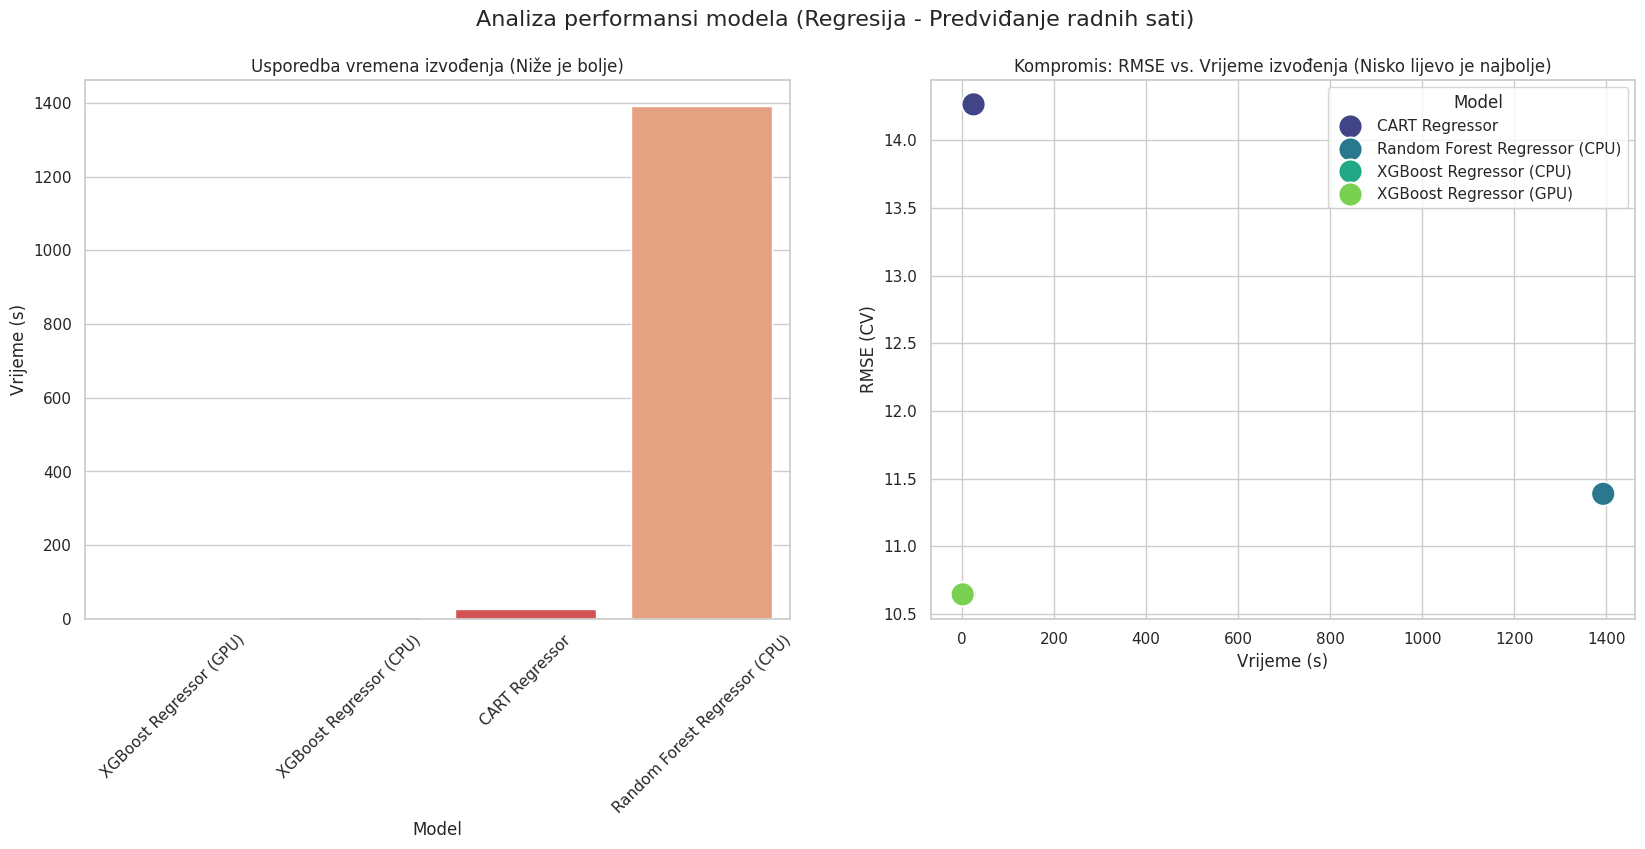


   ADULT SKUP ZAVRŠEN. PODACI SPREMLJENI U: /content/drive/MyDrive/diplomski_rad_podaci/rezultati_eksperimenta


In [42]:
# --- 5. GRAFIČKA USPOREDBA ---
print("\nGeneriranje grafičke usporedbe performansi...")
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 7))
fig.suptitle('Analiza performansi modela (Regresija - Predviđanje radnih sati)', fontsize=16)

sns.barplot(x='Model', y='Vrijeme (s)', data=df_res_adult_reg.sort_values('Vrijeme (s)'), ax=ax1, palette='rocket')
ax1.set_title('Usporedba vremena izvođenja (Niže je bolje)')
ax1.tick_params(axis='x', rotation=45)

sns.scatterplot(data=df_res_adult_reg, x='Vrijeme (s)', y='RMSE (CV)', hue='Model', s=300, ax=ax2, palette='viridis')
ax2.set_title('Kompromis: RMSE vs. Vrijeme izvođenja (Nisko lijevo je najbolje)')

plot_path_adult_reg_perf = os.path.join(results_path, 'adult_reg_03_performanse.png')
plt.savefig(plot_path_adult_reg_perf, dpi=300, bbox_inches='tight')
plt.show()

print(f"\n   ADULT SKUP ZAVRŠEN. PODACI SPREMLJENI U: {results_path}")

# <a id="wine"></a> 4. Analiza skupa podataka: Wine Quality

## 4.1 Regresija

### Priprema podataka

In [43]:
# --- 1. PRIPREMA PODATAKA ---
X_wine_reg = df_wine.drop('quality', axis=1)
y_wine_reg = df_wine['quality']

numeric_features_reg = X_wine_reg.select_dtypes(include=np.number).columns.tolist()
categorical_features_reg = ['type']

preprocessor_wine_reg = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features_reg),
        ('cat', OneHotEncoder(drop='first'), categorical_features_reg)
    ])
print("1. Podaci za regresiju pripremljeni.")

1. Podaci za regresiju pripremljeni.


### EDA

In [44]:
# --- 2. VIZUALIZACIJA CILJNE VARIJABLE ---
print("\n2. Generiranje i spremanje grafa distribucije kvalitete vina...")
plt.figure(figsize=(10, 6))
sns.histplot(y_wine_reg, bins=len(y_wine_reg.unique()), kde=True, color='purple')
plt.title('Distribucija ocjene kvalitete vina (Ciljna varijabla)')
plt.xlabel('Kvaliteta (0-10)')

plot_path_wine_reg_dist = os.path.join(results_path, 'wine_reg_01_distribucija.png')
plt.savefig(plot_path_wine_reg_dist, dpi=300, bbox_inches='tight')
plt.close()


2. Generiranje i spremanje grafa distribucije kvalitete vina...


### Pipeline benchmarking CPU vs GPU modela

In [45]:
# --- 3. GLAVNI BENCHMARKING (CPU vs GPU) ---
print("\n     Pokretanje Benchmarkinga Regresije (10-Fold CV)...")
kf_wine = KFold(n_splits=10, shuffle=True, random_state=42)
scoring_reg = {'neg_rmse': 'neg_root_mean_squared_error', 'r2': 'r2'}

regressors_wine = {
    "CART Regressor": DecisionTreeRegressor(random_state=42),
    "Random Forest Regressor (CPU)": RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    "XGBoost Regressor (CPU)": xgb.XGBRegressor(objective='reg:squarederror', tree_method='hist', device='cpu', random_state=42),
    "XGBoost Regressor (GPU)": xgb.XGBRegressor(objective='reg:squarederror', tree_method='hist', device='cuda', random_state=42)
}

results_cv_wine_reg = []

for name, reg in regressors_wine.items():
    print(f"   Analiziram: {name}...")
    pipeline = Pipeline([('preprocessor', preprocessor_wine_reg), ('regressor', reg)])
    start_time = time.time()

    try:
        cv_scores = cross_validate(pipeline, X_wine_reg, y_wine_reg, cv=kf_wine, scoring=scoring_reg, n_jobs=1)
        end_time = time.time()

        results_cv_wine_reg.append({
            'Model': name,
            'RMSE (CV)': -cv_scores['test_neg_rmse'].mean(),
            'R2 Score (CV)': cv_scores['test_r2'].mean(),
            'Vrijeme (s)': end_time - start_time
        })
    except Exception as e:
        print(f"     Greška pri izvođenju {name}: {e}")

    del pipeline
    if 'cv_scores' in locals(): del cv_scores
    gc.collect()


     Pokretanje Benchmarkinga Regresije (10-Fold CV)...
   Analiziram: CART Regressor...
   Analiziram: Random Forest Regressor (CPU)...
   Analiziram: XGBoost Regressor (CPU)...
   Analiziram: XGBoost Regressor (GPU)...


### Spremanje rezultata u CSV datoteku

In [46]:
# --- 4. SPREMANJE REZULTATA ---
df_res_wine_reg = pd.DataFrame(results_cv_wine_reg)
csv_wine_reg_path = os.path.join(results_path, 'wine_reg_02_rezultati_cv.csv')
df_res_wine_reg.to_csv(csv_wine_reg_path, index=False)
display(df_res_wine_reg.sort_values(by='RMSE (CV)', ascending=True))

,Model,RMSE (CV),R2 Score (CV),Vrijeme (s)
1,Random Forest Regressor (CPU),0.595649,0.533797,39.032071
2,XGBoost Regressor (CPU),0.628259,0.480980,2.382305
3,XGBoost Regressor (GPU),0.628259,0.480980,1.987665
0,CART Regressor,0.812495,0.128844,0.816555


### Grafička usporedba performansi


Generiranje grafičke usporedbe performansi...


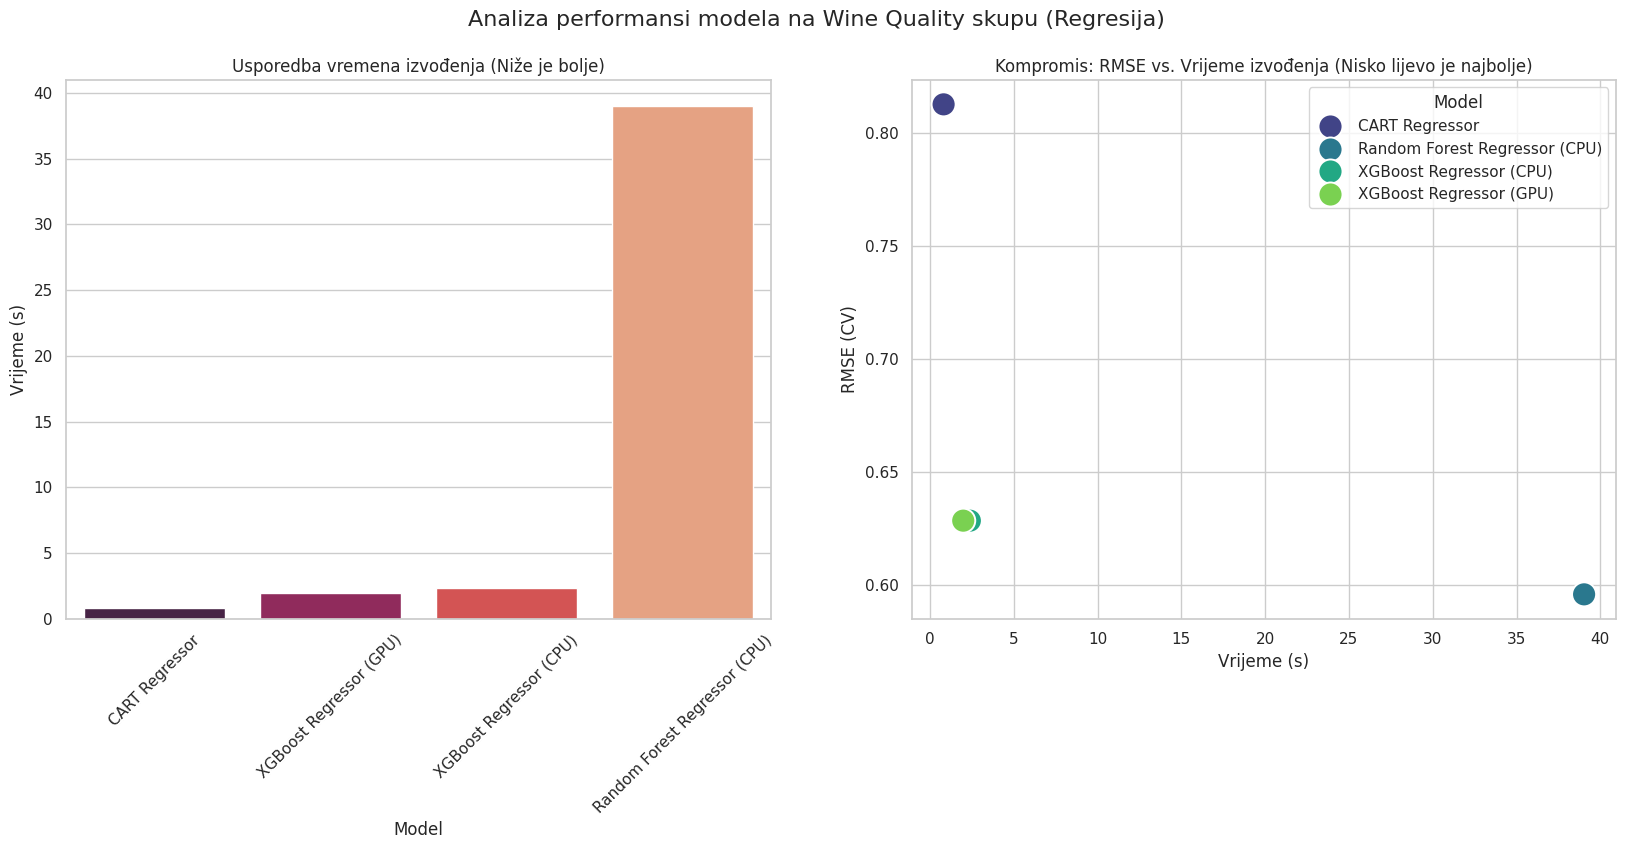


   WINE QUALITY (REGRESIJA) ZAVRŠEN. PODACI SPREMLJENI U: /content/drive/MyDrive/diplomski_rad_podaci/rezultati_eksperimenta


In [47]:
# --- 5. GRAFIČKA USPOREDBA ---
print("\nGeneriranje grafičke usporedbe performansi...")
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 7))
fig.suptitle('Analiza performansi modela na Wine Quality skupu (Regresija)', fontsize=16)

sns.barplot(x='Model', y='Vrijeme (s)', data=df_res_wine_reg.sort_values('Vrijeme (s)'), ax=ax1, palette='rocket')
ax1.set_title('Usporedba vremena izvođenja (Niže je bolje)')
ax1.tick_params(axis='x', rotation=45)

sns.scatterplot(data=df_res_wine_reg, x='Vrijeme (s)', y='RMSE (CV)', hue='Model', s=300, ax=ax2, palette='viridis')
ax2.set_title('Kompromis: RMSE vs. Vrijeme izvođenja (Nisko lijevo je najbolje)')

plot_path_wine_reg_perf = os.path.join(results_path, 'wine_reg_03_performanse.png')
plt.savefig(plot_path_wine_reg_perf, dpi=300, bbox_inches='tight')
plt.show()

print(f"\n   WINE QUALITY (REGRESIJA) ZAVRŠEN. PODACI SPREMLJENI U: {results_path}")

## 4.2 Klasifikacija

### Priprema podataka

In [48]:
# --- 1. PRIPREMA PODATAKA ---
df_wine_class = df_wine.copy()
# Binning u 3 klase
df_wine_class['quality_label'] = pd.cut(df_wine_class['quality'], bins=[0, 4, 6, 10], labels=['low', 'medium', 'high'])

X_wine_class = df_wine_class.drop(['quality', 'quality_label'], axis=1)
y_wine_class_raw = df_wine_class['quality_label']

le_wine = LabelEncoder()
y_wine_class = le_wine.fit_transform(y_wine_class_raw)

# Preprocessor je isti kao kod regresije jer su nezavisne varijable iste
print("1. Podaci za klasifikaciju pripremljeni.")

1. Podaci za klasifikaciju pripremljeni.


### EDA

In [49]:
# --- 2. VIZUALIZACIJA CILJNE VARIJABLE ---
print("\n2. Generiranje i spremanje grafa distribucije novih klasa...")
plt.figure(figsize=(8, 5))
sns.countplot(x=y_wine_class_raw, order=['low', 'medium', 'high'], palette='viridis')
plt.title('Distribucija novih klasa kvalitete vina')

plot_path_wine_clf_dist = os.path.join(results_path, 'wine_clf_01_distribucija.png')
plt.savefig(plot_path_wine_clf_dist, dpi=300, bbox_inches='tight')
plt.close()


2. Generiranje i spremanje grafa distribucije novih klasa...


### Pipeline benchmarking CPU vs GPU modela

In [50]:
# --- 3. GLAVNI BENCHMARKING (CPU vs GPU) ---
print("\n     Pokretanje Benchmarkinga Klasifikacije (10-Fold CV)...")
# Budući da su klase jako neuravnotežene, izračunat ćemo težine uzoraka (sample_weight).
# XGBoost u multi-class problemima koristi 'mlogloss' i ne podržava jednostavan 'scale_pos_weight'.
# Zato ćemo se osloniti na weighted F1-Score da penalizira loše predviđanje manjinskih klasa.

classifiers_wine_clf = {
    "CART (Entropy)": DecisionTreeClassifier(criterion='entropy', random_state=42, class_weight='balanced'),
    "CART (Gini)": DecisionTreeClassifier(criterion='gini', random_state=42, class_weight='balanced'),
    "Random Forest (CPU)": RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced', n_jobs=-1),
    "XGBoost (CPU)": xgb.XGBClassifier(tree_method='hist', device='cpu', eval_metric='mlogloss', random_state=42),
    "XGBoost (GPU)": xgb.XGBClassifier(tree_method='hist', device='cuda', eval_metric='mlogloss', random_state=42)
}

results_cv_wine_clf = []

for name, clf in classifiers_wine_clf.items():
    print(f"   Analiziram: {name}...")
    pipeline = Pipeline([('preprocessor', preprocessor_wine_reg), ('classifier', clf)]) # Koristimo preprocessor_wine_reg
    start_time = time.time()

    try:
        cv_scores = cross_validate(pipeline, X_wine_class, y_wine_class, cv=kf_wine, scoring=['accuracy', 'f1_weighted'], n_jobs=1)
        end_time = time.time()

        results_cv_wine_clf.append({
            'Model': name,
            'Accuracy (CV)': cv_scores['test_accuracy'].mean(),
            'F1-Score (CV)': cv_scores['test_f1_weighted'].mean(),
            'Vrijeme (s)': end_time - start_time
        })
    except Exception as e:
        print(f"     Greška pri izvođenju {name}: {e}")

    del pipeline
    if 'cv_scores' in locals(): del cv_scores
    gc.collect()


     Pokretanje Benchmarkinga Klasifikacije (10-Fold CV)...
   Analiziram: CART (Entropy)...
   Analiziram: CART (Gini)...
   Analiziram: Random Forest (CPU)...
   Analiziram: XGBoost (CPU)...
   Analiziram: XGBoost (GPU)...


### Spremanje rezultata u CSV datoteku

In [51]:
# --- 4. SPREMANJE REZULTATA ---
df_res_wine_clf = pd.DataFrame(results_cv_wine_clf)
csv_wine_clf_path = os.path.join(results_path, 'wine_clf_02_rezultati_cv.csv')
df_res_wine_clf.to_csv(csv_wine_clf_path, index=False)
display(df_res_wine_clf.sort_values(by='F1-Score (CV)', ascending=False))

,Model,Accuracy (CV),F1-Score (CV),Vrijeme (s)
2,Random Forest (CPU),0.863786,0.845615,12.142290
4,XGBoost (GPU),0.854240,0.840994,4.357418
3,XGBoost (CPU),0.853161,0.839197,7.793140
0,CART (Entropy),0.804528,0.803987,0.871369
1,CART (Gini),0.801905,0.800696,0.798207


### Grafička usporedba performansi


Generiranje grafičke usporedbe performansi...


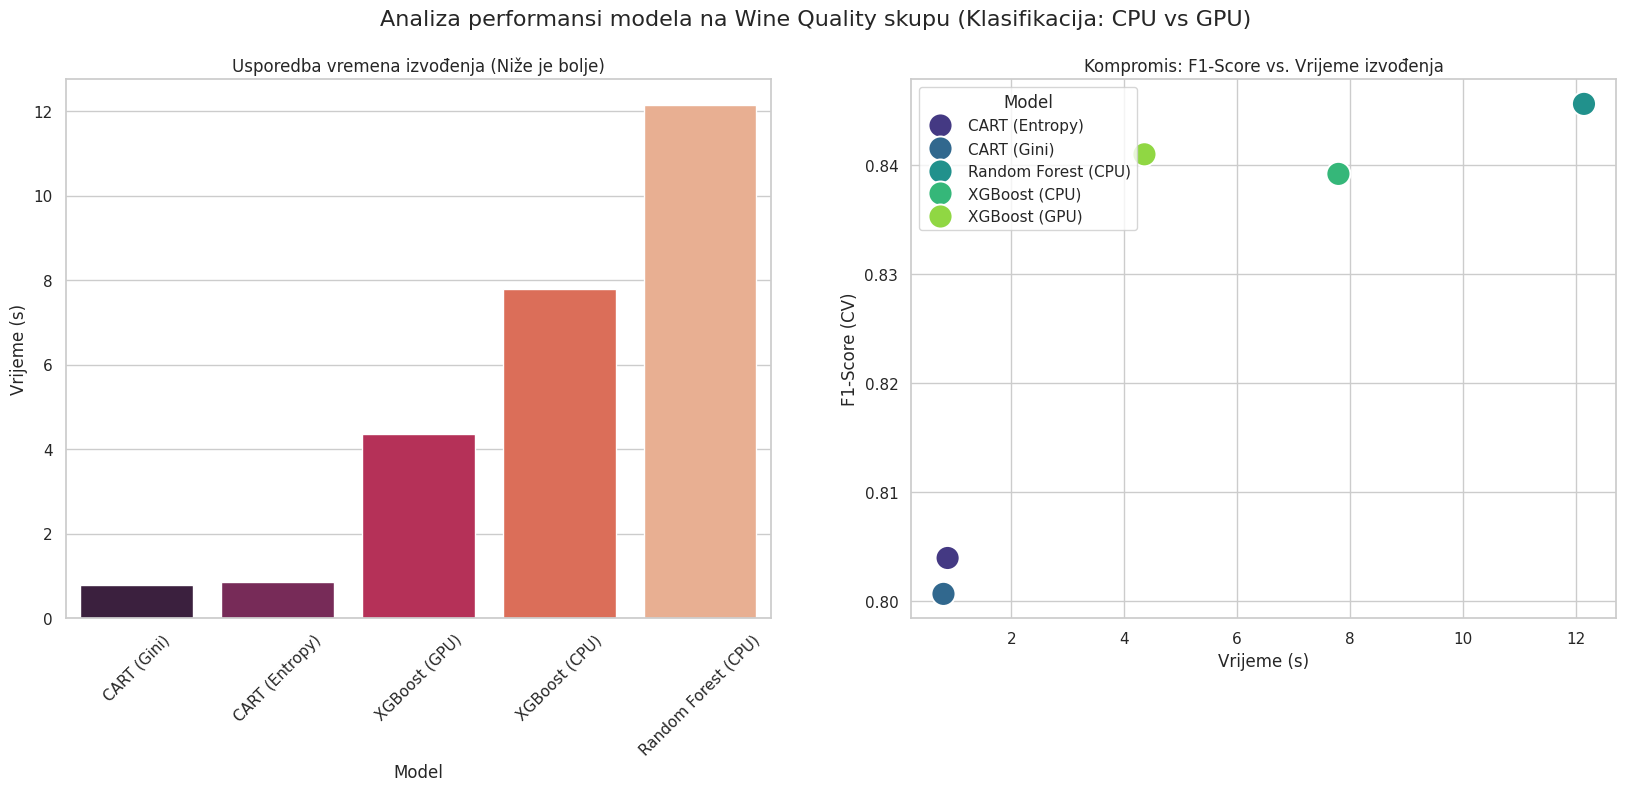


   WINE QUALITY (KLASIFIKACIJA) ZAVRŠEN. PODACI SPREMLJENI U: /content/drive/MyDrive/diplomski_rad_podaci/rezultati_eksperimenta


In [52]:
# --- 5. GRAFIČKA USPOREDBA ---
print("\nGeneriranje grafičke usporedbe performansi...")
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 7))
fig.suptitle('Analiza performansi modela na Wine Quality skupu (Klasifikacija: CPU vs GPU)', fontsize=16)

sns.barplot(x='Model', y='Vrijeme (s)', data=df_res_wine_clf.sort_values('Vrijeme (s)'), ax=ax1, palette='rocket')
ax1.set_title('Usporedba vremena izvođenja (Niže je bolje)')
ax1.tick_params(axis='x', rotation=45)

sns.scatterplot(data=df_res_wine_clf, x='Vrijeme (s)', y='F1-Score (CV)', hue='Model', s=300, ax=ax2, palette='viridis')
ax2.set_title('Kompromis: F1-Score vs. Vrijeme izvođenja')

plot_path_wine_clf_perf = os.path.join(results_path, 'wine_clf_03_performanse.png')
plt.savefig(plot_path_wine_clf_perf, dpi=300, bbox_inches='tight')
plt.show()

print(f"\n   WINE QUALITY (KLASIFIKACIJA) ZAVRŠEN. PODACI SPREMLJENI U: {results_path}")

# <a id="cancer"></a> 5. Analiza skupa podataka: Breast Cancer Wisconsin

## 5.1 Klasifikacija

### Priprema podataka

In [53]:
from scipy import stats
import numpy as np

# --- 1. PRIPREMA PODATAKA ---
X_cancer = df_cancer.drop(['id', 'diagnosis'], axis=1)
y_cancer_raw = df_cancer['diagnosis']

le_cancer = LabelEncoder()
y_cancer = le_cancer.fit_transform(y_cancer_raw)

preprocessor_cancer = StandardScaler()
print("1. Podaci su pripremljeni (Standardno skaliranje).")





1. Podaci su pripremljeni (Standardno skaliranje).


### EDA

In [54]:
# --- 2. VIZUALIZACIJA ---
print("\n2. Generiranje i spremanje grafa distribucije i matricu korelacije...")
plt.figure(figsize=(8, 5))
sns.countplot(x=y_cancer_raw, palette='viridis')
plt.title('Distribucija klasa u Breast Cancer skupu (Beningno vs Maligno)')
plot_path_cancer_dist = os.path.join(results_path, 'cancer_01_distribucija.png')
plt.savefig(plot_path_cancer_dist, dpi=300, bbox_inches='tight')
plt.close()

plt.figure(figsize=(12, 10))
sns.heatmap(X_cancer.corr(), annot=False, cmap='coolwarm')
plt.title('Matrica korelacije značajki (Breast Cancer)')
plot_path_cancer_corr = os.path.join(results_path, 'cancer_02_korelacija.png')
plt.savefig(plot_path_cancer_corr, dpi=300, bbox_inches='tight')
plt.close()



2. Generiranje i spremanje grafa distribucije i matricu korelacije...


### Pipeline benchmarking CPU vs GPU modela

In [55]:
# --- 3. GLAVNI BENCHMARKING (CPU vs GPU) ---
print("\n     Pokretanje Benchmarkinga Klasifikacije (10-Fold CV)...")
kf_cancer = KFold(n_splits=10, shuffle=True, random_state=42)

classifiers_cancer = {
    "CART (Entropy)": DecisionTreeClassifier(criterion='entropy', random_state=42, class_weight='balanced'),
    "CART (Gini)": DecisionTreeClassifier(criterion='gini', random_state=42, class_weight='balanced'),
    "Random Forest (CPU)": RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced', n_jobs=-1),
    "XGBoost (CPU)": xgb.XGBClassifier(tree_method='hist', device='cpu', eval_metric='logloss', random_state=42),
    "XGBoost (GPU)": xgb.XGBClassifier(tree_method='hist', device='cuda', eval_metric='logloss', random_state=42)
}

results_cv_cancer = []
# Ovi rječnici će nam trebati za statistički test!
fold_results_rf = []
fold_results_xgb = []

for name, clf in classifiers_cancer.items():
    print(f"   Analiziram: {name}...")
    pipeline = Pipeline([('preprocessor', preprocessor_cancer), ('classifier', clf)])
    start_time = time.time()

    try:
        cv_scores = cross_validate(pipeline, X_cancer, y_cancer, cv=kf_cancer, scoring=['roc_auc', 'f1_weighted'], n_jobs=1)
        end_time = time.time()

        # Spremamo svaki fold rezultat ako je model RF ili XGBoost(CPU) za t-test
        if name == "Random Forest (CPU)": fold_results_rf = cv_scores['test_roc_auc']
        if name == "XGBoost (CPU)": fold_results_xgb = cv_scores['test_roc_auc']

        results_cv_cancer.append({
            'Model': name,
            'ROC AUC (CV)': cv_scores['test_roc_auc'].mean(),
            'F1-Score (CV)': cv_scores['test_f1_weighted'].mean(),
            'Vrijeme (s)': end_time - start_time
        })
    except Exception as e:
        print(f"     Greška pri izvođenju {name}: {e}")

    del pipeline
    if 'cv_scores' in locals(): del cv_scores
    gc.collect()


     Pokretanje Benchmarkinga Klasifikacije (10-Fold CV)...
   Analiziram: CART (Entropy)...
   Analiziram: CART (Gini)...
   Analiziram: Random Forest (CPU)...
   Analiziram: XGBoost (CPU)...
   Analiziram: XGBoost (GPU)...


### Spremanje rezultata u CSV datoteku

In [56]:
# --- 4. SPREMANJE REZULTATA ---
df_res_cancer = pd.DataFrame(results_cv_cancer)
csv_cancer_path = os.path.join(results_path, 'cancer_03_rezultati_cv.csv')
df_res_cancer.to_csv(csv_cancer_path, index=False)
display(df_res_cancer.sort_values(by='ROC AUC (CV)', ascending=False))


,Model,ROC AUC (CV),F1-Score (CV),Vrijeme (s)
2,Random Forest (CPU),0.993613,0.968323,4.475277
3,XGBoost (CPU),0.992414,0.966514,1.437359
4,XGBoost (GPU),0.992250,0.966639,1.204050
0,CART (Entropy),0.932317,0.938279,0.239341
1,CART (Gini),0.921819,0.924465,0.249104


### Grafička usporedba performansi


Generiranje grafičke usporedbe performansi...


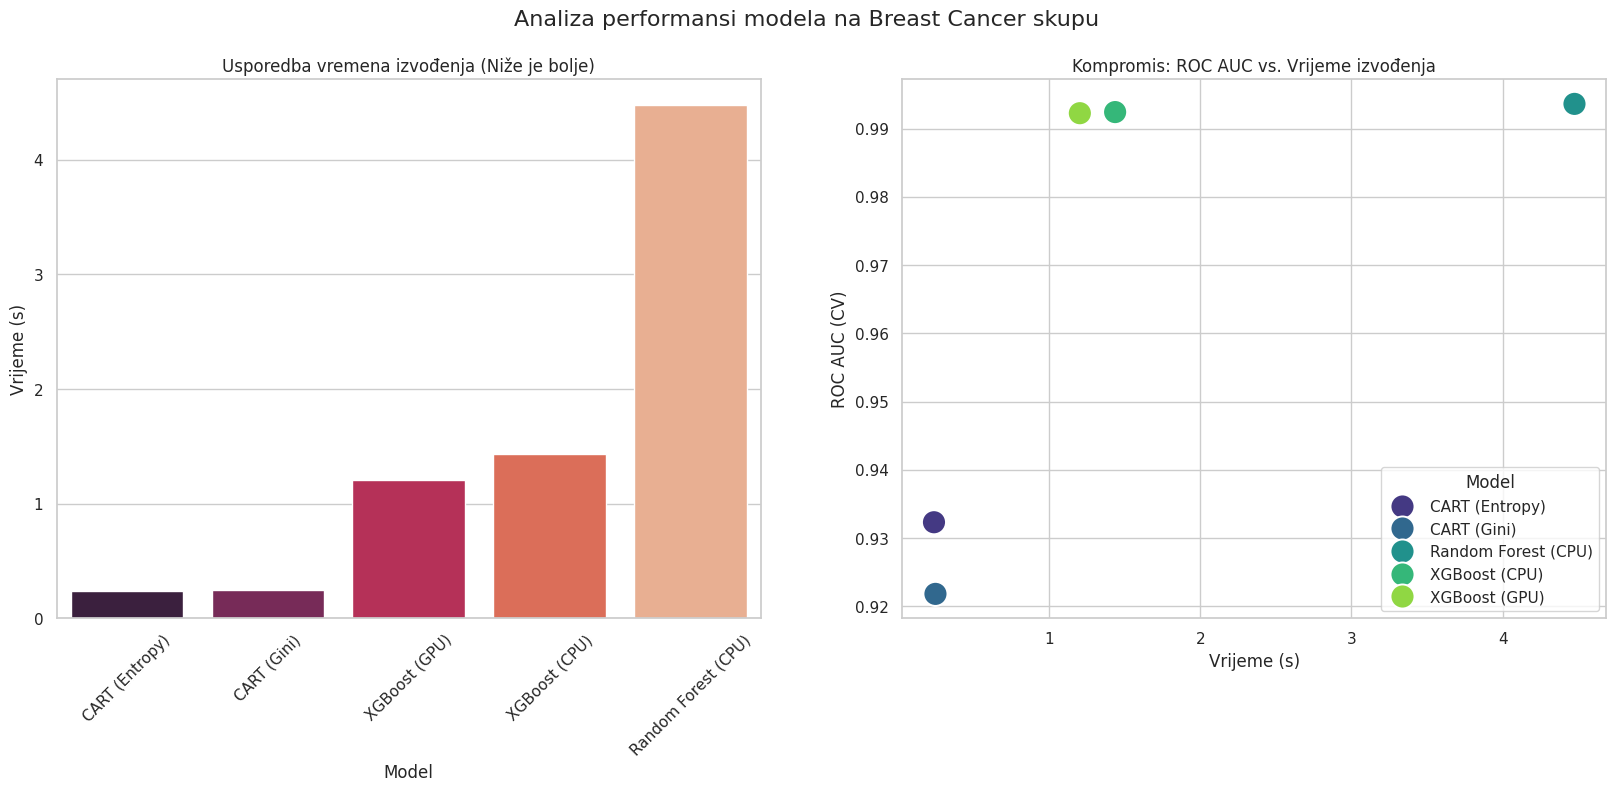

In [57]:
### --- 5. GRAFIČKA USPOREDBA ---
print("\nGeneriranje grafičke usporedbe performansi...")
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 7))
fig.suptitle('Analiza performansi modela na Breast Cancer skupu', fontsize=16)

sns.barplot(x='Model', y='Vrijeme (s)', data=df_res_cancer.sort_values('Vrijeme (s)'), ax=ax1, palette='rocket')
ax1.set_title('Usporedba vremena izvođenja (Niže je bolje)')
ax1.tick_params(axis='x', rotation=45)

sns.scatterplot(data=df_res_cancer, x='Vrijeme (s)', y='ROC AUC (CV)', hue='Model', s=300, ax=ax2, palette='viridis')
ax2.set_title('Kompromis: ROC AUC vs. Vrijeme izvođenja')

plot_path_cancer_perf = os.path.join(results_path, 'cancer_04_performanse.png')
plt.savefig(plot_path_cancer_perf, dpi=300, bbox_inches='tight')
plt.show()

## 5.2 Statističko testiranje značajnosti (Nadeau and Bengio korigirani t-test)

In [58]:
# Funkcija za Korigirani upareni t-test za k-fold CV
def corrected_paired_ttest(scores1, scores2, n_folds):
    differences = scores1 - scores2
    n = len(differences)
    mean_diff = np.mean(differences)
    var_diff = np.var(differences, ddof=1)

    # Omjer veličine testnog i trening skupa (za 10-fold je to 1/9)
    # Jer u 10-foldu testiramo na 1 foldu, a treniramo na 9
    test_train_ratio = 1 / (n_folds - 1)

    # Korekcija varijance (Nadeau and Bengio)
    corrected_var = var_diff * (1/n + test_train_ratio)

    t_stat = mean_diff / np.sqrt(corrected_var)
    # p-vrijednost dvostranog t-testa s n-1 stupnjeva slobode
    p_value = stats.t.sf(np.abs(t_stat), n-1) * 2
    return t_stat, p_value

if len(fold_results_rf) > 0 and len(fold_results_xgb) > 0:
    t_stat, p_value = corrected_paired_ttest(fold_results_xgb, fold_results_rf, n_folds=10)

    alpha = 0.05
    print(f"  Korigirani upareni t-test (Nadeau & Bengio korekcija za CV):")
    print(f"   - T-Statistika: {t_stat:.4f}")
    print(f"   - P-vrijednost: {p_value:.4f}")

    print("\n  ZAKLJUČAK:")
    if p_value < alpha:
        print(f"      ODBACUJEMO nultu hipotezu (p < {alpha}).")
        print("   Postoji STATISTIČKI ZNAČAJNA RAZLIKA u ROC AUC performansama između Random Foresta i XGBoosta.")
        if np.mean(fold_results_xgb) > np.mean(fold_results_rf):
             print("   🏆 XGBoost je značajno bolji.")
        else:
             print("   🏆 Random Forest je značajno bolji.")
    else:
        print(f"     NE ODBACUJEMO nultu hipotezu (p >= {alpha}).")
        print("   NE POSTOJI statistički značajna razlika u ROC AUC performansama. Razlike su mogle nastati slučajno.")
else:
    print("  Nije moguće provesti statistički test (Modeli nisu uspjeli izvesti CV).")

print(f"\n   BREAST CANCER SKUP I STATISTIČKA ANALIZA ZAVRŠENI. SPREMLJENO U: {results_path}")

  Korigirani upareni t-test (Nadeau & Bengio korekcija za CV):
   - T-Statistika: -0.4232
   - P-vrijednost: 0.6821

  ZAKLJUČAK:
     NE ODBACUJEMO nultu hipotezu (p >= 0.05).
   NE POSTOJI statistički značajna razlika u ROC AUC performansama. Razlike su mogle nastati slučajno.

   BREAST CANCER SKUP I STATISTIČKA ANALIZA ZAVRŠENI. SPREMLJENO U: /content/drive/MyDrive/diplomski_rad_podaci/rezultati_eksperimenta


# Završna usporedba svih modela

## Zbirna evaluacija za modele klasifikacije

### Prikupljanje podataka iz memorije

In [59]:
# ==============================================================================
# ZAVRŠNA SINTEZA: GLOBALNA EVALUACIJA SVIH MODELA I STATISTIKA
# ==============================================================================
print("\n" + "="*50)
print("ZAPOČINJE GLOBALNA ZAVRŠNA ANALIZA (DEMŠAR METODOLOGIJA)")
print("="*50)

# --- 1. PRIKUPLJANJE PODATAKA IZ MEMORIJE ---
# Rječnik: Ime zadatka -> (Ime DataFrame-a, Stupac s metrikom, Više je bolje?)
# Uključujemo sve zadatke (klasifikacija i regresija)
all_tasks = {
    'Iris (Klasi.)': ('df_res_iris', 'F1-Score (CV)', True),
    'Bank (Klasi.)': ('df_res_bank', 'ROC AUC (CV)', True),
    'Bank (Regre.)': ('df_res_bank_reg', 'RMSE (CV)', False), # Kod regresije je manji RMSE bolji!
    'Adult (Klasi.)': ('df_res_adult', 'ROC AUC (CV)', True),
    'Adult (Regre.)': ('df_res_adult_reg', 'RMSE (CV)', False),
    'Wine (Klasi.)': ('df_res_wine_clf', 'F1-Score (CV)', True),
    'Wine (Regre.)': ('df_res_wine_reg', 'RMSE (CV)', False),
    'Cancer (Klasi.)': ('df_res_cancer', 'ROC AUC (CV)', True)
}

# Modeli koje pratimo kroz cijeli rad
target_models = ['CART (Entropy)', 'CART (Gini)', 'Random Forest (CPU)', 'XGBoost (CPU)', 'XGBoost (GPU)']

global_results = []
rank_data = {} # Za Friedmanov test

for task_name, (df_name, metric_col, higher_is_better) in all_tasks.items():
    if df_name in locals():
        df = locals()[df_name].copy()

        # Ostavljamo samo modele koje želimo usporediti
        df = df[df['Model'].isin(target_models)]

        # Izrada rangova za ovaj zadatak (1 = najbolji, 5 = najgori)
        # Ako je higher_is_better (npr. ROC AUC), množimo s -1 da najveći broj dobije rang 1
        metric_values = df[metric_col].values
        if higher_is_better:
            ranks = stats.rankdata(-metric_values)
        else:
            ranks = stats.rankdata(metric_values)

        # Spremanje u tablicu rangova
        rank_data[task_name] = {model: rank for model, rank in zip(df['Model'], ranks)}

        # Dodavanje metapodataka za graf vremena
        for _, row in df.iterrows():
            global_results.append({
                'Zadatak': task_name,
                'Model': row['Model'],
                'Vrijeme (s)': row['Vrijeme (s)']
            })
    else:
        print(f"  Upozorenje: DataFrame {df_name} nije u memoriji. Preskačem.")

df_global_time = pd.DataFrame(global_results)
df_ranks = pd.DataFrame.from_dict(rank_data, orient='index')




ZAPOČINJE GLOBALNA ZAVRŠNA ANALIZA (DEMŠAR METODOLOGIJA)


### Zbirna evaluacija računske složenosti


Generiram zbirni graf vremena izvođenja...


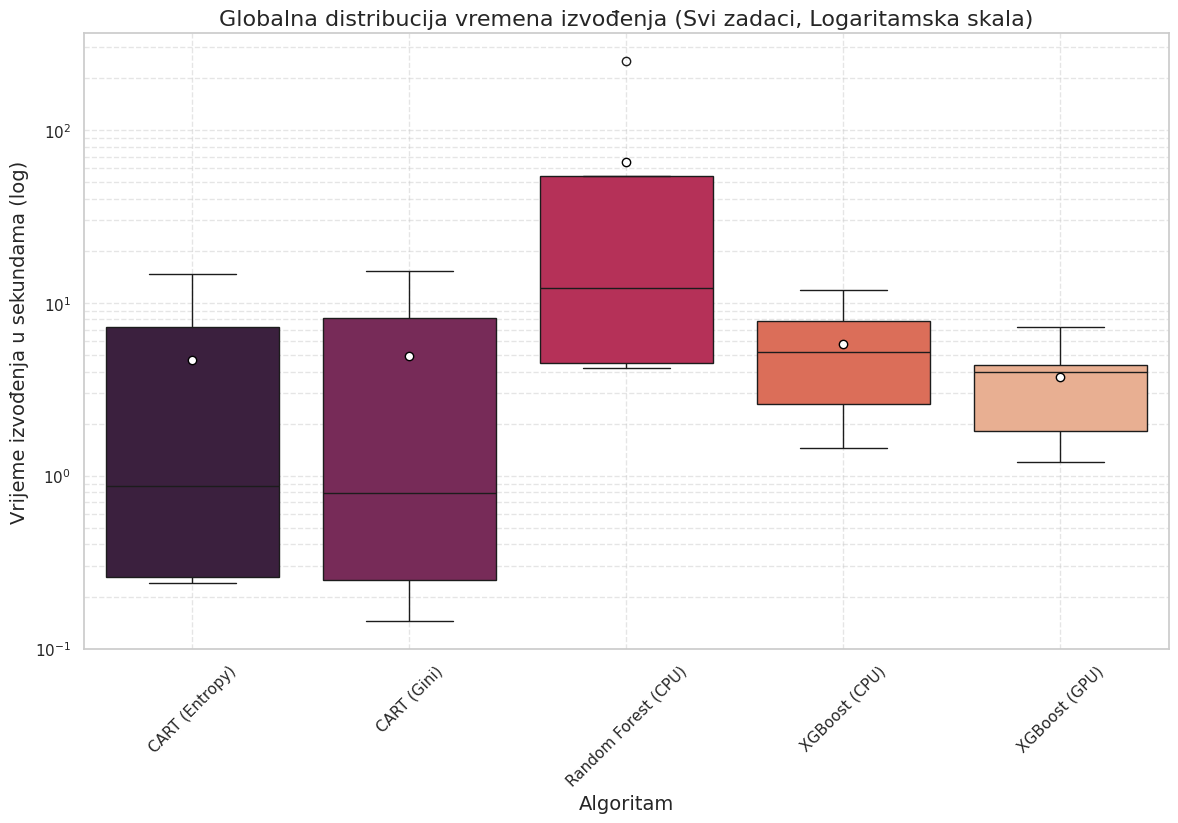

In [60]:
# --- 2. ZBIRNA EVALUACIJA RAČUNSKE SLOŽENOSTI (Graf vremena) ---
print("\nGeneriram zbirni graf vremena izvođenja...")
plt.figure(figsize=(14, 8))
# Boxplot savršeno prikazuje varijancu vremena algoritma kroz SVE skupove
sns.boxplot(data=df_global_time, x='Model', y='Vrijeme (s)', palette='rocket', showmeans=True,
            meanprops={"marker":"o", "markerfacecolor":"white", "markeredgecolor":"black"})
plt.yscale('log')
plt.title('Globalna distribucija vremena izvođenja (Svi zadaci, Logaritamska skala)', fontsize=16)
plt.ylabel('Vrijeme izvođenja u sekundama (log)', fontsize=14)
plt.xlabel('Algoritam', fontsize=14)
plt.xticks(rotation=45)
plt.grid(True, which="both", ls="--", alpha=0.5)

plot_path_global_time = os.path.join(results_path, 'global_01_vrijeme_boxplot.png')
plt.savefig(plot_path_global_time, dpi=300, bbox_inches='tight')
plt.show()



### Tablica rangova

In [61]:
# --- 3. TABLICA RANGOVA ---
print("\n--- GLOBALNA TABLICA RANGOVA (1 = Najbolji) ---")
# Računamo prosječan rang svakog algoritma
df_ranks.loc['PROSJEČAN RANG'] = df_ranks.mean()
display(df_ranks.style.background_gradient(cmap='RdYlGn_r', axis=1))

df_ranks.to_csv(os.path.join(results_path, 'global_02_rangovi.csv'))




--- GLOBALNA TABLICA RANGOVA (1 = Najbolji) ---


,CART (Entropy),CART (Gini),Random Forest (CPU),XGBoost (CPU),XGBoost (GPU)
Iris (Klasi.),3.500000,3.500000,1.000000,5.000000,2.000000
Bank (Klasi.),5.000000,4.000000,1.000000,3.000000,2.000000
Adult (Klasi.),4.000000,5.000000,3.000000,2.000000,1.000000
Wine (Klasi.),4.000000,5.000000,1.000000,3.000000,2.000000
Cancer (Klasi.),4.000000,5.000000,1.000000,2.000000,3.000000
PROSJEČAN RANG,4.100000,4.500000,1.400000,3.000000,2.000000


### Friedmanov test

In [62]:
# --- 4. FRIEDMANOV TEST ---
print("\n--- STATISTIČKO TESTIRANJE (FRIEDMAN + NEMENYI) ---")
# Prikupit ćemo rangove kao listu lista (svaka lista je jedan algoritam kroz sve zadatke)
# Izbacujemo redak 'PROSJEČAN RANG' za statistiku
df_ranks_stats = df_ranks.drop('PROSJEČAN RANG')
model_arrays = [df_ranks_stats[col].values for col in df_ranks_stats.columns]

stat, p_value = stats.friedmanchisquare(*model_arrays)
print(f"Friedmanov test statistika: {stat:.4f}")
print(f"P-vrijednost: {p_value:.6f}")

alpha = 0.05
if p_value < alpha:
    print(f"\n   ODBACUJEMO nultu hipotezu (p < {alpha}).")
    print("Postoji statistički značajna razlika u performansama između algoritama na razini cijelog istraživanja.")
    print("Prelazimo na Nemenyi Post-hoc test...")




--- STATISTIČKO TESTIRANJE (FRIEDMAN + NEMENYI) ---
Friedmanov test statistika: 14.1818
P-vrijednost: 0.006737

   ODBACUJEMO nultu hipotezu (p < 0.05).
Postoji statistički značajna razlika u performansama između algoritama na razini cijelog istraživanja.
Prelazimo na Nemenyi Post-hoc test...


### Nemenyi test i CD dijagram


   ODBACUJEMO nultu hipotezu (p < 0.05). Postoji značajna razlika!
Provodim Nemenyi Post-Hoc test...


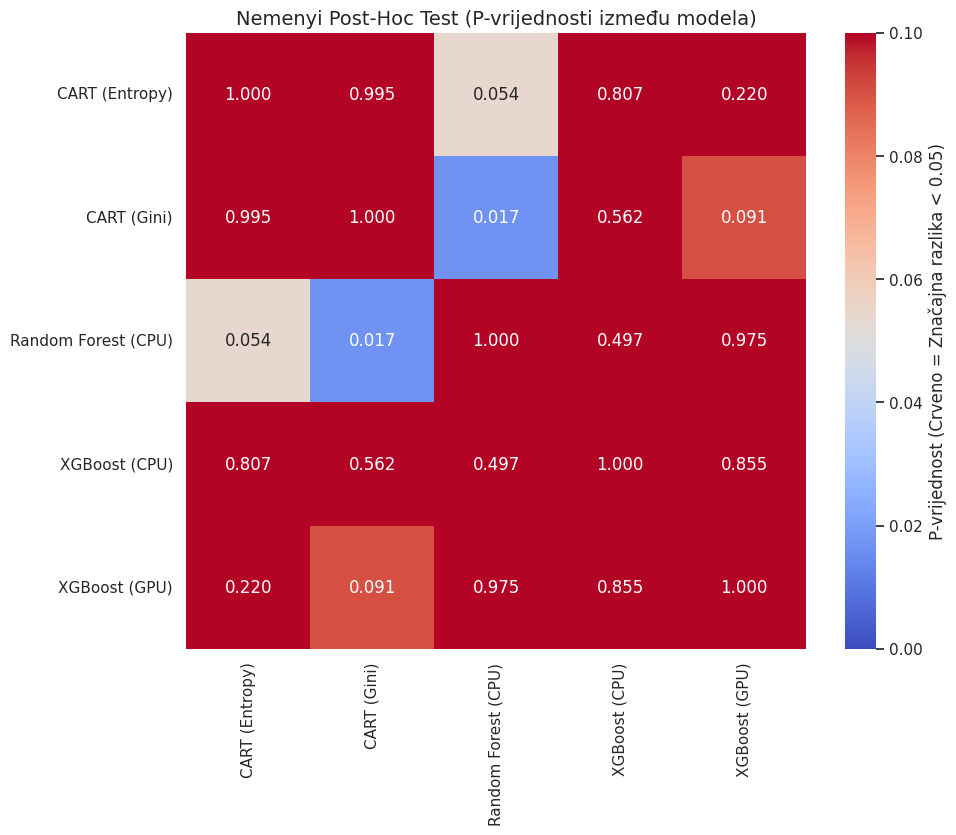


Tumačenje Nemenyi matrice:
Ako je p-vrijednost između dva algoritma manja od 0.05 (crvena polja),
to znači da je razlika između njih statistički značajna!

   GLOBALNA ANALIZA ZAVRŠENA. SVI REZULTATI SPREMLJENI U: /content/drive/MyDrive/diplomski_rad_podaci/rezultati_eksperimenta


In [63]:
# --- 5. NEMENYI TEST I CRITICAL DIFFERENCE DIJAGRAM ---
alpha = 0.05

if p_value < alpha:
    print(f"\n   ODBACUJEMO nultu hipotezu (p < {alpha}). Postoji značajna razlika!")
    print("Provodim Nemenyi Post-Hoc test...")

    # scikit-posthocs traži format gdje su redovi mjerenja, a stupci algoritmi
    nemenyi_results = sp.posthoc_nemenyi_friedman(df_ranks_stats)

    # Generiranje Heatmape p-vrijednosti Nemenyi testa
    plt.figure(figsize=(10, 8))
    sns.heatmap(nemenyi_results, annot=True, cmap='coolwarm', vmin=0, vmax=0.1, fmt=".3f",
                cbar_kws={'label': 'P-vrijednost (Crveno = Značajna razlika < 0.05)'})
    plt.title('Nemenyi Post-Hoc Test (P-vrijednosti između modela)', fontsize=14)

    plot_path_nemenyi = os.path.join(results_path, 'global_03_nemenyi_heatmap.png')
    plt.savefig(plot_path_nemenyi, dpi=300, bbox_inches='tight')
    plt.show()

    print("\nTumačenje Nemenyi matrice:")
    print("Ako je p-vrijednost između dva algoritma manja od 0.05 (crvena polja),")
    print("to znači da je razlika između njih statistički značajna!")

else:
    print(f"\n  NE ODBACUJEMO nultu hipotezu (p = {p_value:.4f} >= {alpha}).")
    print("Nema statistički značajne razlike između algoritama na trenutnom broju skupova podataka.")

print(f"\n   GLOBALNA ANALIZA ZAVRŠENA. SVI REZULTATI SPREMLJENI U: {results_path}")